# Bank Risk Connectedness and Financial Stress Analysis

This notebook analyzes how major U.S. bank equity return correlations change across financial stress regimes.
It covers descriptive analysis, stress vs. calm period comparison, rolling interbank correlation,
regression modeling with HAC standard errors, ANOVA-based model comparison, and expanding-window out-of-sample RMSE validation.

**Data:** `../data/raw/bank_returns_and_financial_stress_daily.xlsx`  
**Banks:** AIG, BAC, C, GS, JPM, MS, PNC, USB, WFC  
**Stress indicators:** VIX (VIXCLS), St. Louis Fed Financial Stress Index (STLFSI)  
**Sample period:** January 2010 – March 2020


In [4]:
import pandas as pd

path = "../data/raw/bank_returns_and_financial_stress_daily.xlsx"
df = pd.read_excel(path, index_col=0, parse_dates=True)

df.head()


,AIG,BAC,C,GS,JPM,MS,PNC,USB,WFC,MKT,VIXCLS,STLFSI,stress
Date,,,,,,,,,,,,,
2010-01-05,-0.018913,0.031988,0.037522,0.017525,0.019185,0.035905,0.010040,0.025034,0.027083,0.003111,20.04,-0.116,0
2010-01-06,-0.006499,0.011660,0.030686,-0.010731,0.005479,0.012716,0.000000,0.010600,0.001424,0.000545,19.35,-0.116,0
2010-01-07,-0.019405,0.032416,0.002744,0.019379,0.019615,0.014380,0.052792,0.019216,0.035643,0.003993,19.16,-0.116,0
2010-01-08,0.026244,-0.008899,-0.016575,-0.019092,-0.002459,-0.020562,0.002629,0.001654,-0.009312,0.002878,19.06,-0.116,0
2010-01-11,0.009836,0.008899,0.011080,-0.015903,-0.003363,-0.006533,0.002796,0.004533,-0.002081,0.001745,18.13,-0.186,0


In [5]:
df.info()
df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2472 entries, 2010-01-05 to 2020-03-13
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AIG     2472 non-null   float64
 1   BAC     2472 non-null   float64
 2   C       2472 non-null   float64
 3   GS      2472 non-null   float64
 4   JPM     2472 non-null   float64
 5   MS      2472 non-null   float64
 6   PNC     2472 non-null   float64
 7   USB     2472 non-null   float64
 8   WFC     2472 non-null   float64
 9   MKT     2472 non-null   float64
 10  VIXCLS  2472 non-null   float64
 11  STLFSI  2472 non-null   float64
 12  stress  2472 non-null   int64  
dtypes: float64(12), int64(1)
memory usage: 270.4 KB


,0
AIG,0
BAC,0
C,0
GS,0
JPM,0
MS,0
PNC,0
USB,0
WFC,0
MKT,0


In [6]:
import numpy as np
import pandas as pd

banks = ["AIG","BAC","C","GS","JPM","MS","PNC","USB","WFC"]


descriptive statistics for bank returns


In [7]:
desc_all = df[banks].describe().T
desc_all


,count,mean,std,min,25%,50%,75%,max
AIG,2472.0,0.000114,0.020406,-0.233761,-0.008083,0.000516,0.008687,0.151307
BAC,2472.0,0.000210,0.021256,-0.227129,-0.009630,0.000358,0.010555,0.163786
C,2472.0,0.000249,0.020550,-0.179336,-0.008788,0.000407,0.009744,0.165381
GS,2472.0,0.000067,0.017281,-0.136864,-0.008321,0.000445,0.009056,0.161951
JPM,2472.0,0.000516,0.016659,-0.145552,-0.007245,0.000511,0.008656,0.165620
MS,2472.0,0.000220,0.021561,-0.163460,-0.009824,0.000349,0.011171,0.180403
PNC,2472.0,0.000421,0.015688,-0.145622,-0.006755,0.000718,0.008478,0.121717
USB,2472.0,0.000354,0.014444,-0.155959,-0.005929,0.000770,0.007328,0.160144
WFC,2472.0,0.000195,0.016297,-0.172779,-0.007413,0.000283,0.008125,0.127215


Annualized Volatility


In [8]:
desc_all["ann_vol"] = desc_all["std"] * np.sqrt(252)
desc_all


,count,mean,std,min,25%,50%,75%,max,ann_vol
AIG,2472.0,0.000114,0.020406,-0.233761,-0.008083,0.000516,0.008687,0.151307,0.323934
BAC,2472.0,0.000210,0.021256,-0.227129,-0.009630,0.000358,0.010555,0.163786,0.337422
C,2472.0,0.000249,0.020550,-0.179336,-0.008788,0.000407,0.009744,0.165381,0.326221
GS,2472.0,0.000067,0.017281,-0.136864,-0.008321,0.000445,0.009056,0.161951,0.274329
JPM,2472.0,0.000516,0.016659,-0.145552,-0.007245,0.000511,0.008656,0.165620,0.264451
MS,2472.0,0.000220,0.021561,-0.163460,-0.009824,0.000349,0.011171,0.180403,0.342264
PNC,2472.0,0.000421,0.015688,-0.145622,-0.006755,0.000718,0.008478,0.121717,0.249037
USB,2472.0,0.000354,0.014444,-0.155959,-0.005929,0.000770,0.007328,0.160144,0.229295
WFC,2472.0,0.000195,0.016297,-0.172779,-0.007413,0.000283,0.008125,0.127215,0.258710


stress vs calm


In [9]:
desc_stress = df[df["stress"] == 1][banks].describe().T
desc_stress

,count,mean,std,min,25%,50%,75%,max
AIG,248.0,-0.001168,0.039859,-0.233761,-0.022451,-0.001549,0.020604,0.151307
BAC,248.0,-0.003553,0.043556,-0.227129,-0.026124,-0.000957,0.017066,0.163786
C,248.0,-0.002225,0.041905,-0.179336,-0.022477,0.001839,0.020463,0.165381
GS,248.0,-0.001577,0.031637,-0.131696,-0.019164,-0.000787,0.017516,0.161951
JPM,248.0,-0.001005,0.033697,-0.145552,-0.021814,-0.000358,0.018777,0.165620
MS,248.0,-0.001962,0.042966,-0.163460,-0.019755,-0.001593,0.020097,0.180403
PNC,248.0,-0.001140,0.031367,-0.145622,-0.020418,0.000578,0.017083,0.121717
USB,248.0,-0.001382,0.031375,-0.155959,-0.017974,0.000849,0.014664,0.160144
WFC,248.0,-0.001694,0.033356,-0.172779,-0.020685,-0.000745,0.017165,0.127215


In [10]:
desc_calm = df[df["stress"] == 0][banks].describe().T
desc_calm


,count,mean,std,min,25%,50%,75%,max
AIG,2224.0,0.000257,0.016915,-0.174846,-0.007551,0.000633,0.008315,0.123713
BAC,2224.0,0.000630,0.017019,-0.077339,-0.008490,0.000584,0.010115,0.082555
C,2224.0,0.000525,0.016539,-0.098239,-0.008114,0.000319,0.009106,0.070490
GS,2224.0,0.000250,0.014846,-0.136864,-0.007753,0.000516,0.008631,0.091153
JPM,2224.0,0.000685,0.013492,-0.097374,-0.006392,0.000531,0.008185,0.067939
MS,2224.0,0.000463,0.017635,-0.107031,-0.009050,0.000381,0.010437,0.108119
PNC,2224.0,0.000595,0.012804,-0.066671,-0.006136,0.000718,0.008024,0.052792
USB,2224.0,0.000548,0.011053,-0.057757,-0.005380,0.000765,0.006969,0.045120
WFC,2224.0,0.000406,0.013083,-0.096779,-0.006902,0.000301,0.007683,0.073110


Summary Comparison: Stress vs. Calm Periods


In [11]:
summary_stats = pd.DataFrame({
    "Mean (All)": desc_all["mean"],
    "Mean (Stress)": desc_stress["mean"],
    "Mean (Calm)": desc_calm["mean"],
    "Std (All)": desc_all["std"],
    "Std (Stress)": desc_stress["std"],
    "Std (Calm)": desc_calm["std"],
})

summary_stats


,Mean (All),Mean (Stress),Mean (Calm),Std (All),Std (Stress),Std (Calm)
AIG,0.000114,-0.001168,0.000257,0.020406,0.039859,0.016915
BAC,0.000210,-0.003553,0.000630,0.021256,0.043556,0.017019
C,0.000249,-0.002225,0.000525,0.020550,0.041905,0.016539
GS,0.000067,-0.001577,0.000250,0.017281,0.031637,0.014846
JPM,0.000516,-0.001005,0.000685,0.016659,0.033697,0.013492
MS,0.000220,-0.001962,0.000463,0.021561,0.042966,0.017635
PNC,0.000421,-0.001140,0.000595,0.015688,0.031367,0.012804
USB,0.000354,-0.001382,0.000548,0.014444,0.031375,0.011053
WFC,0.000195,-0.001694,0.000406,0.016297,0.033356,0.013083


Systemic Risk Proxy: Average Interbank Correlation


In [12]:
def mean_pairwise_corr(data):
    corr = data.corr().values
    return np.mean(corr[np.triu_indices_from(corr, k=1)])

mean_corr_all = mean_pairwise_corr(df[banks])
mean_corr_stress = mean_pairwise_corr(df[df["stress"] == 1][banks])
mean_corr_calm = mean_pairwise_corr(df[df["stress"] == 0][banks])

mean_corr_all, mean_corr_stress, mean_corr_calm


(np.float64(0.7493092680852906),
 np.float64(0.855534250622939),
 np.float64(0.6785992528710659))

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

banks = ["AIG","BAC","C","GS","JPM","MS","PNC","USB","WFC"]


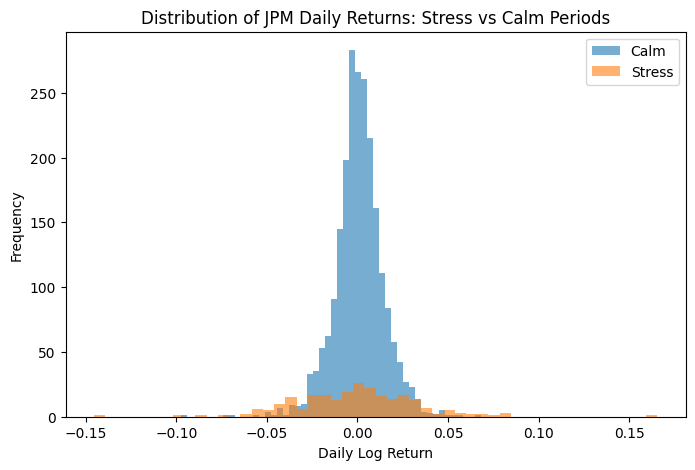

In [14]:
plt.figure(figsize=(8,5))

plt.hist(df[df["stress"]==0]["JPM"], bins=50, alpha=0.6, label="Calm")
plt.hist(df[df["stress"]==1]["JPM"], bins=50, alpha=0.6, label="Stress")

plt.title("Distribution of JPM Daily Returns: Stress vs Calm Periods")
plt.xlabel("Daily Log Return")
plt.ylabel("Frequency")
plt.legend()
plt.show()


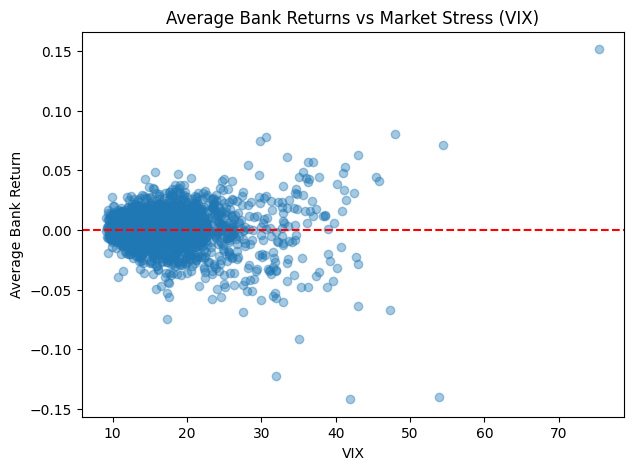

In [15]:
df["avg_bank_ret"] = df[banks].mean(axis=1)

plt.figure(figsize=(7,5))
plt.scatter(df["VIXCLS"], df["avg_bank_ret"], alpha=0.4)
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("VIX")
plt.ylabel("Average Bank Return")
plt.title("Average Bank Returns vs Market Stress (VIX)")
plt.show()


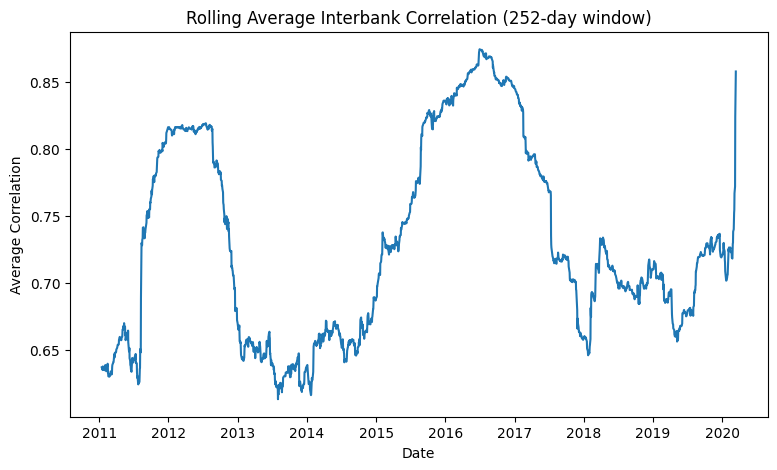

In [16]:
window = 252

rolling_corr = (
    df[banks]
    .rolling(window)
    .corr()
)

#  pairwise correlation
avg_corr = []

dates = df.index[window:]

for t in range(window, len(df)):
    corr_t = df[banks].iloc[t-window:t].corr().values
    avg_corr.append(
        np.mean(corr_t[np.triu_indices_from(corr_t, k=1)])
    )

plt.figure(figsize=(9,5))
plt.plot(dates, avg_corr)
plt.title("Rolling Average Interbank Correlation (252-day window)")
plt.xlabel("Date")
plt.ylabel("Average Correlation")
plt.show()


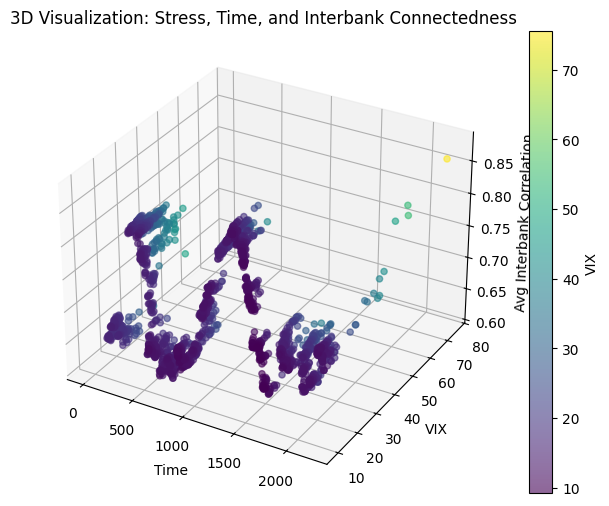

In [17]:
from mpl_toolkits.mplot3d import Axes3D

vix_series = df.loc[dates, "VIXCLS"].values
corr_series = np.array(avg_corr)
time_numeric = np.arange(len(dates))

fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    time_numeric,
    vix_series,
    corr_series,
    c=vix_series,
    cmap="viridis",
    alpha=0.6
)

ax.set_xlabel("Time")
ax.set_ylabel("VIX")
ax.set_zlabel("Avg Interbank Correlation")
ax.set_title("3D Visualization: Stress, Time, and Interbank Connectedness")

plt.colorbar(sc, label="VIX")
plt.show()


Average Correlation (1yr)


In [18]:
avg_corr = []

for i in range(window, len(df)):
    sub = df[banks].iloc[i-window:i]
    corr_matrix = sub.corr()

    # average excluding diagonal
    avg = corr_matrix.values[np.triu_indices_from(corr_matrix, k=1)].mean()
    avg_corr.append(avg)

avg_corr = pd.Series(avg_corr, index=df.index[window:], name="AvgCorr")

df_analysis = df.loc[avg_corr.index].copy()
df_analysis["AvgCorr"] = avg_corr

In [19]:
df_analysis

,AIG,BAC,C,GS,JPM,MS,PNC,USB,WFC,MKT,VIXCLS,STLFSI,stress,avg_bank_ret,AvgCorr
Date,,,,,,,,,,,,,,,
2011-01-14,-0.057395,0.031981,0.017700,0.019795,0.010295,0.023744,0.049312,0.022913,0.026610,0.007357,16.39,-0.495,0,0.016106,0.637247
2011-01-19,-0.041277,-0.042908,-0.008368,-0.048021,-0.023514,-0.035402,-0.022872,-0.029354,-0.021152,-0.010167,15.87,-0.568,0,-0.030319,0.635209
2011-01-20,0.020118,0.011761,0.008368,-0.004816,0.023514,0.044749,-0.013191,0.006765,0.002512,-0.001296,17.31,-0.568,0,0.011087,0.637948
2011-01-21,-0.004177,-0.020147,0.018576,0.003073,0.011995,0.033546,-0.002791,0.009691,0.019255,0.002411,17.99,-0.568,0,0.007669,0.637357
2011-01-24,-0.024722,-0.023430,-0.006154,0.000602,-0.005980,-0.008702,-0.005771,-0.004462,0.005828,0.005819,18.47,-0.564,0,-0.008088,0.636716
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-09,-0.142634,-0.159025,-0.176399,-0.109720,-0.145552,-0.109512,-0.145622,-0.155959,-0.132723,-0.079010,41.94,-0.942,1,-0.141905,0.772119
2020-03-10,0.066613,0.073815,0.078769,0.064644,0.074827,0.051960,0.089910,0.061920,0.077007,0.048215,54.46,-0.942,1,0.071051,0.824107
2020-03-11,-0.078262,-0.040628,-0.090124,-0.069981,-0.048214,-0.068903,-0.058117,-0.064953,-0.081636,-0.050103,47.30,-0.942,1,-0.066758,0.833742


Standardizing STLFSI (stress)


In [20]:
df_analysis["Stress"] = (
    df_analysis["STLFSI"] - df_analysis["STLFSI"].mean()
) / df_analysis["STLFSI"].std()


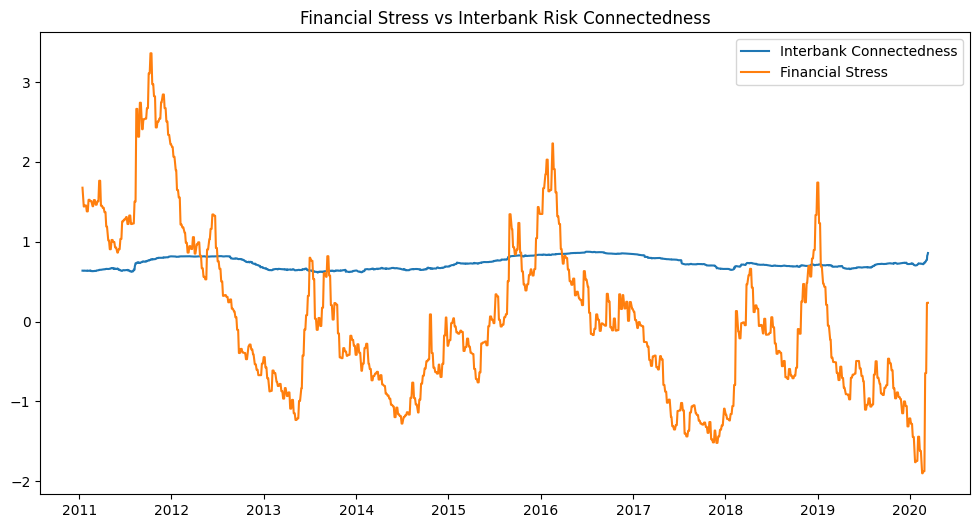

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df_analysis.index, df_analysis["AvgCorr"], label="Interbank Connectedness")
plt.plot(df_analysis.index, df_analysis["Stress"], label="Financial Stress")

plt.legend()
plt.title("Financial Stress vs Interbank Risk Connectedness")
plt.show()


Starting with Simple Linear Regression


In [22]:
import statsmodels.api as sm

X = df_analysis["Stress"]
X = sm.add_constant(X)

y = df_analysis["AvgCorr"]

model = sm.OLS(y, X).fit()
print(model.summary())

residuals = model.resid
fitted = model.fittedvalues


                            OLS Regression Results                            
Dep. Variable:                AvgCorr   R-squared:                       0.127
Model:                            OLS   Adj. R-squared:                  0.127
Method:                 Least Squares   F-statistic:                     322.4
Date:                Tue, 05 May 2026   Prob (F-statistic):           2.02e-67
Time:                        17:57:39   Log-Likelihood:                 2804.9
No. Observations:                2220   AIC:                            -5606.
Df Residuals:                    2218   BIC:                            -5594.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7297      0.001    502.459      0.0

Assumption Check (Residuals)


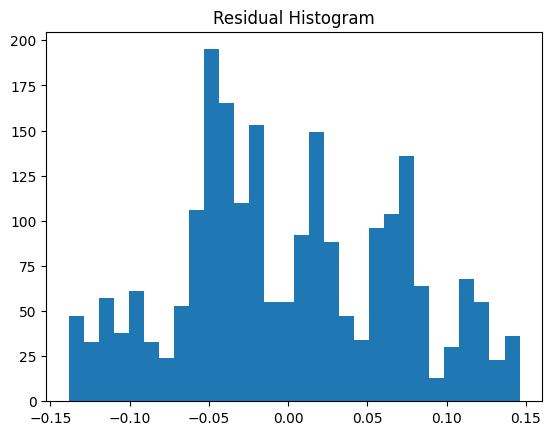

In [23]:
import matplotlib.pyplot as plt

plt.hist(residuals, bins=30)
plt.title("Residual Histogram")
plt.show()

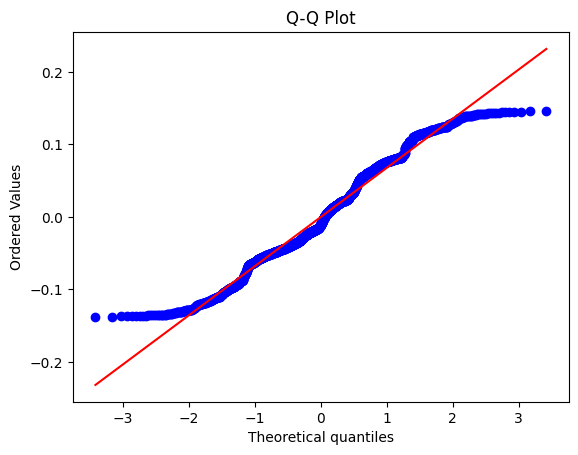

In [24]:
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

In [25]:
from scipy.stats import shapiro

stat, p = shapiro(residuals)
print(p)

6.502547060366028e-18


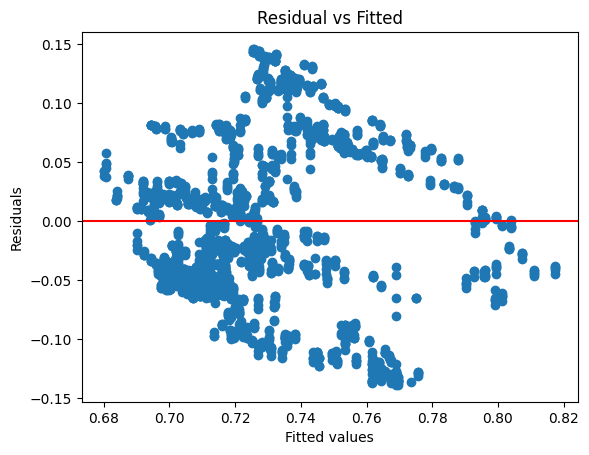

In [26]:
plt.scatter(fitted, residuals)
plt.axhline(0, color='red')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residual vs Fitted")
plt.show()

It seems the assumptions are violated (non-constant variance + shapiro p-value < 0.05)


In [27]:
model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags':20})
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                AvgCorr   R-squared:                       0.127
Model:                            OLS   Adj. R-squared:                  0.127
Method:                 Least Squares   F-statistic:                     21.78
Date:                Tue, 05 May 2026   Prob (F-statistic):           3.25e-06
Time:                        17:57:39   Log-Likelihood:                 2804.9
No. Observations:                2220   AIC:                            -5606.
Df Residuals:                    2218   BIC:                            -5594.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7297      0.007    110.773      0.0

Adding lagged Correlation (time-series)


In [28]:
df_analysis["LagCorr"] = df_analysis["AvgCorr"].shift(1)
df_reg = df_analysis.dropna()

X = df_reg[["Stress","LagCorr"]]
X = sm.add_constant(X)
y = df_reg["AvgCorr"]

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                AvgCorr   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 6.291e+05
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        17:57:39   Log-Likelihood:                 9691.4
No. Observations:                2219   AIC:                        -1.938e+04
Df Residuals:                    2216   BIC:                        -1.936e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0017      0.001      2.414      0.0

Objective #1 (testing the comovement)


Regression (baseline model)


*** Check the basic assumptions of regression model (epsilon iid normally distributed) - graph for epsilon and X then justify our model selection


In [29]:
df_analysis.head()

,AIG,BAC,C,GS,JPM,MS,PNC,USB,WFC,MKT,VIXCLS,STLFSI,stress,avg_bank_ret,AvgCorr,Stress,LagCorr
Date,,,,,,,,,,,,,,,,,
2011-01-14,-0.057395,0.031981,0.017700,0.019795,0.010295,0.023744,0.049312,0.022913,0.026610,0.007357,16.39,-0.495,0,0.016106,0.637247,1.676269,NaN
2011-01-19,-0.041277,-0.042908,-0.008368,-0.048021,-0.023514,-0.035402,-0.022872,-0.029354,-0.021152,-0.010167,15.87,-0.568,0,-0.030319,0.635209,1.440805,0.637247
2011-01-20,0.020118,0.011761,0.008368,-0.004816,0.023514,0.044749,-0.013191,0.006765,0.002512,-0.001296,17.31,-0.568,0,0.011087,0.637948,1.440805,0.635209
2011-01-21,-0.004177,-0.020147,0.018576,0.003073,0.011995,0.033546,-0.002791,0.009691,0.019255,0.002411,17.99,-0.568,0,0.007669,0.637357,1.440805,0.637948
2011-01-24,-0.024722,-0.023430,-0.006154,0.000602,-0.005980,-0.008702,-0.005771,-0.004462,0.005828,0.005819,18.47,-0.564,0,-0.008088,0.636716,1.453707,0.637357


In [30]:
import pandas as pd
import statsmodels.api as sm


X = df_analysis[['VIXCLS', 'Stress']]
X = sm.add_constant(X)  # intercept
y = df_analysis['AvgCorr']

model = sm.OLS(y, X).fit()
residuals = model.resid
fitted = model.fittedvalues

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                AvgCorr   R-squared:                       0.137
Model:                            OLS   Adj. R-squared:                  0.136
Method:                 Least Squares   F-statistic:                     175.5
Date:                Tue, 05 May 2026   Prob (F-statistic):           1.83e-71
Time:                        17:57:40   Log-Likelihood:                 2817.3
No. Observations:                2220   AIC:                            -5629.
Df Residuals:                    2217   BIC:                            -5612.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7576      0.006    131.748      0.0

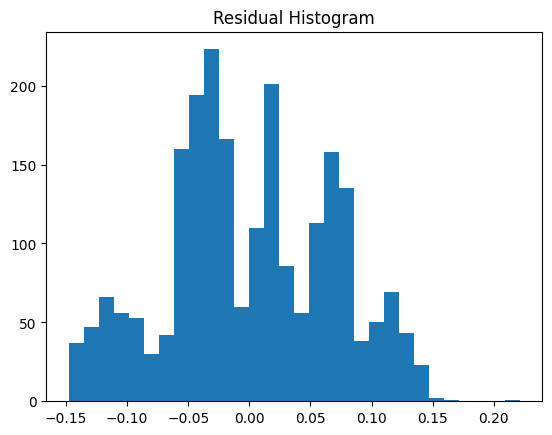

In [31]:
import matplotlib.pyplot as plt

plt.hist(residuals, bins=30)
plt.title("Residual Histogram")
plt.show()

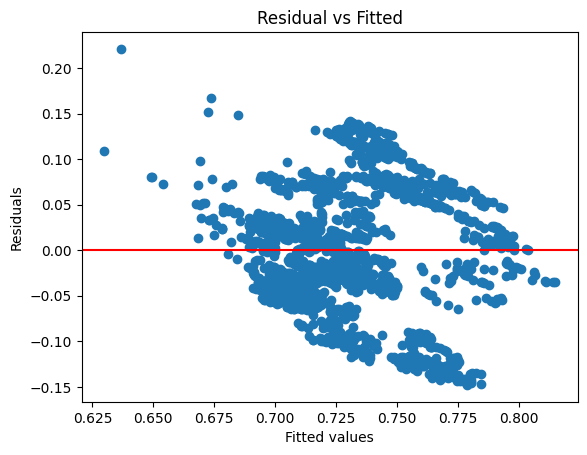

In [32]:
plt.scatter(fitted, residuals)
plt.axhline(0, color='red')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residual vs Fitted")
plt.show()

In [33]:
from scipy.stats import shapiro

stat, p = shapiro(residuals)
print(p)

1.0265711601472963e-15


Assumption doesn't work (we should try quadratic model)


Compare between full(VIX + Stress) vs restricted(VIX)


In [34]:
import statsmodels.api as sm

# Full model (VIXCLS + Stress)
X_full = df_analysis[['VIXCLS', 'Stress']]
X_full = sm.add_constant(X_full)
y = df_analysis['AvgCorr']

model_full = sm.OLS(y, X_full).fit()

# Restricted model (VIXCLS only)
X_restricted = df_analysis[['VIXCLS']]
X_restricted = sm.add_constant(X_restricted)

model_restricted = sm.OLS(y, X_restricted).fit()

# F-test
f_test_result = model_full.compare_f_test(model_restricted)

print("F-stat:", f_test_result[0])
print("p-value:", f_test_result[1])
print("df diff:", f_test_result[2])

F-stat: 280.91857594135337
p-value: 1.8523628574928307e-59
df diff: 1.0


Compare between full(VIX + Stress) vs restricted(Stress)


In [35]:
import statsmodels.api as sm

# Full model (VIXCLS + Stress)
X_full = df_analysis[['VIXCLS', 'Stress']]
X_full = sm.add_constant(X_full)
y = df_analysis['AvgCorr']

model_full = sm.OLS(y, X_full).fit()

# Restricted model (Stress only)
X_restricted = df_analysis[['Stress']]
X_restricted = sm.add_constant(X_restricted)

model_restricted = sm.OLS(y, X_restricted).fit()

# F-test
f_test_result = model_full.compare_f_test(model_restricted)

print("F-stat:", f_test_result[0])
print("p-value:", f_test_result[1])
print("df diff:", f_test_result[2])

F-stat: 24.989884242506346
p-value: 6.214633253241271e-07
df diff: 1.0


Test if beta1 = beta2 (should scale the same!)


In [36]:
# H0: VIXCLS = Stress
hypothesis = 'VIXCLS = Stress'

wald_test = model.f_test(hypothesis)

print(wald_test)

<F test: F=245.8890834297693, p=1.2367000917546182e-52, df_denom=2.22e+03, df_num=1>


it's not the same. they are totally different factors


*** Also try the models other than linear model (ex. polynomial)


Single-factor ANOVA


H0 : u0 = u1


In [37]:
from scipy import stats

group0 = df_analysis[df_analysis['stress'] == 0]['AvgCorr']
group1 = df_analysis[df_analysis['stress'] == 1]['AvgCorr']

t_stat, p_val = stats.ttest_ind(group0, group1)

print(t_stat, p_val)

-6.718215331730536 2.3305136247287675e-11


they are different


In [38]:
import pandas as pd
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

anova_model = ols('AvgCorr ~ stress', data=df_analysis).fit()
anova_results = anova_lm(anova_model)
print(anova_results)

              df     sum_sq   mean_sq          F        PR(>F)
stress       1.0   0.237241  0.237241  45.134417  2.330514e-11
Residual  2218.0  11.658526  0.005256        NaN           NaN


<Axes: xlabel='stress', ylabel='AvgCorr'>

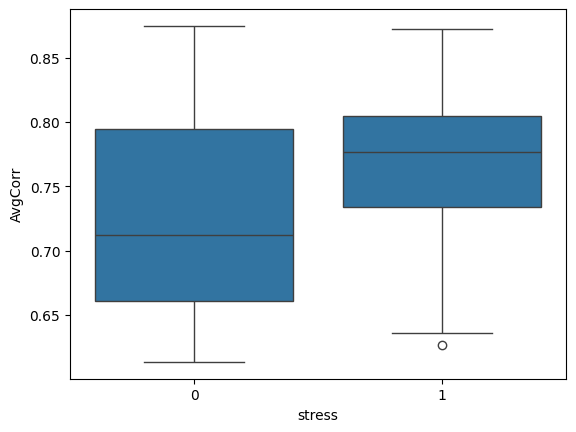

In [39]:
import seaborn as sns
sns.boxplot(x='stress', y='AvgCorr', data=df_analysis)

Comparison of Correlation by Heat Map


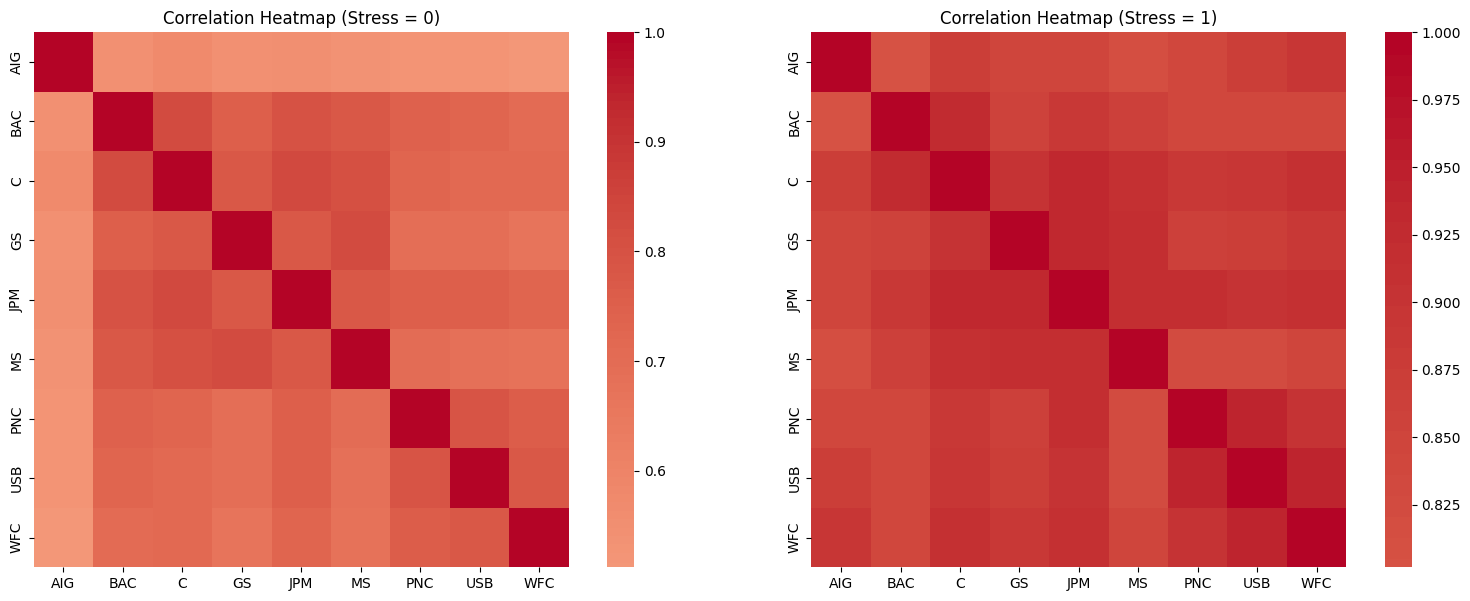

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# set columns
cols = ['AIG','BAC','C','GS','JPM','MS','PNC','USB','WFC']

# stress=0 / stress=1
df_stress0 = df_analysis[df_analysis['stress'] == 0]
df_stress1 = df_analysis[df_analysis['stress'] == 1]

# correlation
corr0 = df_stress0[cols].corr()
corr1 = df_stress1[cols].corr()

# subplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# stress = 0
sns.heatmap(corr0, ax=axes[0], cmap='coolwarm', center=0, square=True)
axes[0].set_title('Correlation Heatmap (Stress = 0)')

# stress = 1
sns.heatmap(corr1, ax=axes[1], cmap='coolwarm', center=0, square=True)
axes[1].set_title('Correlation Heatmap (Stress = 1)')

plt.tight_layout()
plt.show()

ANCOVA


In [41]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

model = smf.ols('AvgCorr ~ stress + VIXCLS', data=df_analysis).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

             sum_sq      df          F    PR(>F)
stress     0.005046     1.0   0.967231  0.325479
VIXCLS     0.092009     1.0  17.635745  0.000028
Residual  11.566517  2217.0        NaN       NaN


In [42]:
model = smf.ols('AvgCorr ~ stress + VIXCLS + MKT', data=df_analysis).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

             sum_sq      df          F    PR(>F)
stress     0.005105     1.0   0.978013  0.322798
VIXCLS     0.091234     1.0  17.479406  0.000030
MKT        0.000094     1.0   0.017943  0.893453
Residual  11.566424  2216.0        NaN       NaN


market factor is not significant for the correlation of returns


In [43]:
model_interaction = smf.ols(
    'AvgCorr ~ stress * VIXCLS',
    data=df_analysis
).fit()

anova_table_inter = sm.stats.anova_lm(model_interaction, typ=2)
print(anova_table_inter)
print(model_interaction.summary())

                  sum_sq      df          F    PR(>F)
stress          0.005046     1.0   0.969055  0.325023
VIXCLS          0.092009     1.0  17.669003  0.000027
stress:VIXCLS   0.026979     1.0   5.180937  0.022931
Residual       11.539538  2216.0        NaN       NaN
                            OLS Regression Results                            
Dep. Variable:                AvgCorr   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     22.80
Date:                Tue, 05 May 2026   Prob (F-statistic):           1.55e-14
Time:                        17:57:42   Log-Likelihood:                 2688.0
No. Observations:                2220   AIC:                            -5368.
Df Residuals:                    2216   BIC:                            -5345.
Df Model:                           3                                         
Covariance Type:   

interaction term is significant


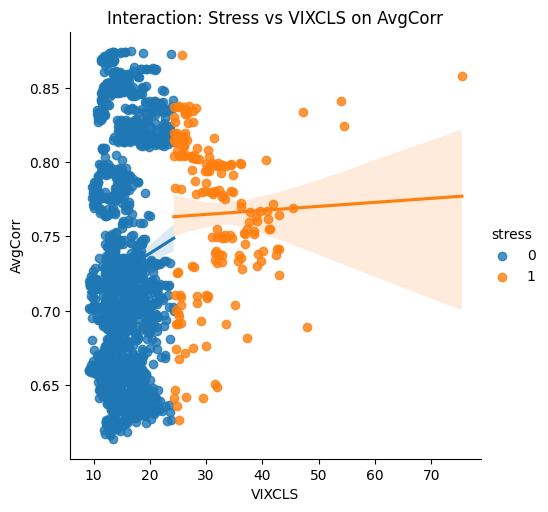

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lmplot(x='VIXCLS', y='AvgCorr', hue='stress', data=df_analysis)
plt.title('Interaction: Stress vs VIXCLS on AvgCorr')
plt.show()

*** group by stress then correlation (explain the purpose)


Interestingly, while the slope of AvgCorr versus VIX is larger in the low-stress regime (Stress=0), the overall level of AvgCorr is higher in the high-stress regime (Stress=1). This indicates that in crisis periods, bank correlations are already elevated, so additional market volatility (VIX) has a smaller marginal effect on AvgCorr.


Objective #2 (rolling-window analysis)


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# rolling window size
window = 60

# rolling AvgCorr
df_analysis['AvgCorr_roll'] = df_analysis['AvgCorr'].rolling(window).mean()

# rolling Stress
df_analysis['Stress_roll'] = df_analysis['stress'].rolling(window).mean()


df_analysis['Regime_roll'] = np.where(df_analysis['Stress_roll'] > 0.5, 'Stress', 'Calm')


df_analysis.groupby('Regime_roll')['AvgCorr_roll'].mean()

,AvgCorr_roll
Regime_roll,
Calm,0.729438
Stress,0.761037


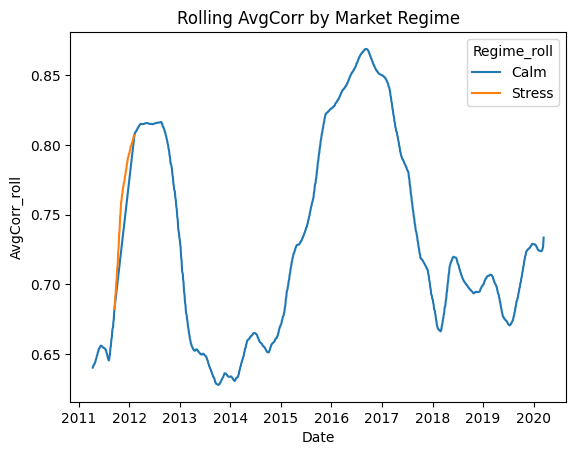

In [46]:
sns.lineplot(x=df_analysis.index, y='AvgCorr_roll', hue='Regime_roll', data=df_analysis)
plt.title('Rolling AvgCorr by Market Regime')
plt.show()

VAR


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


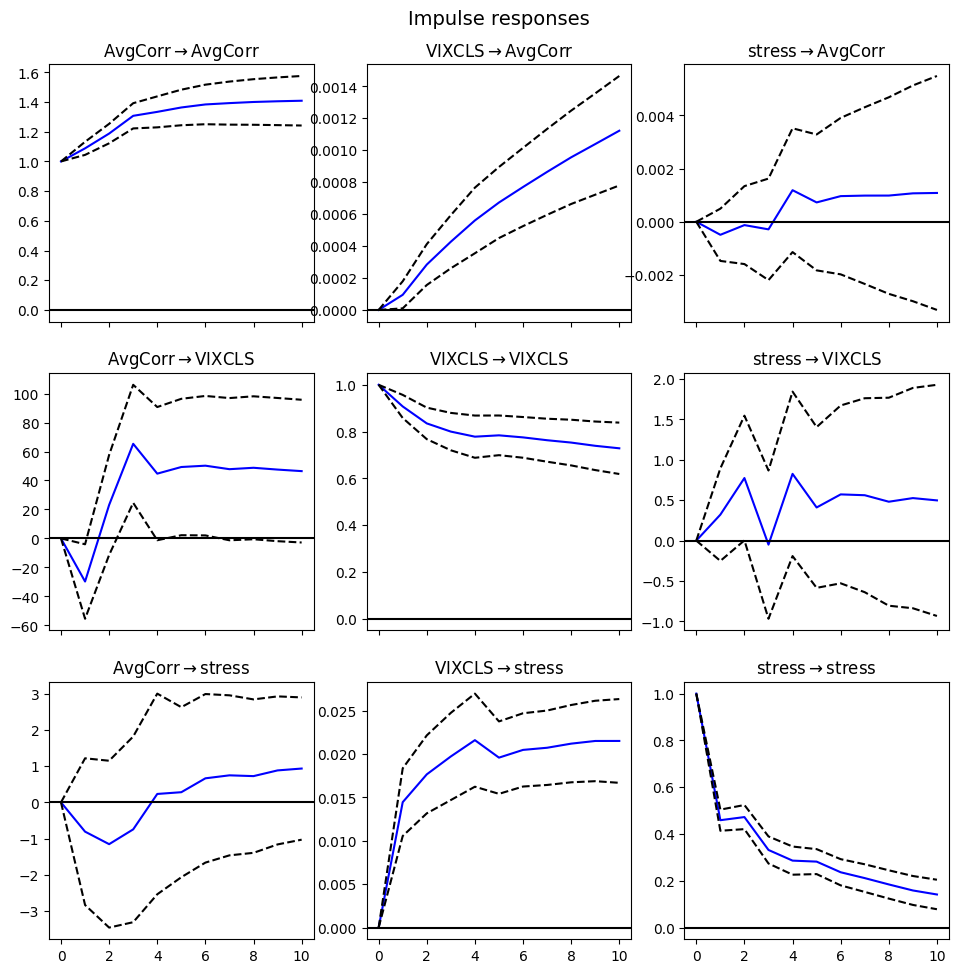

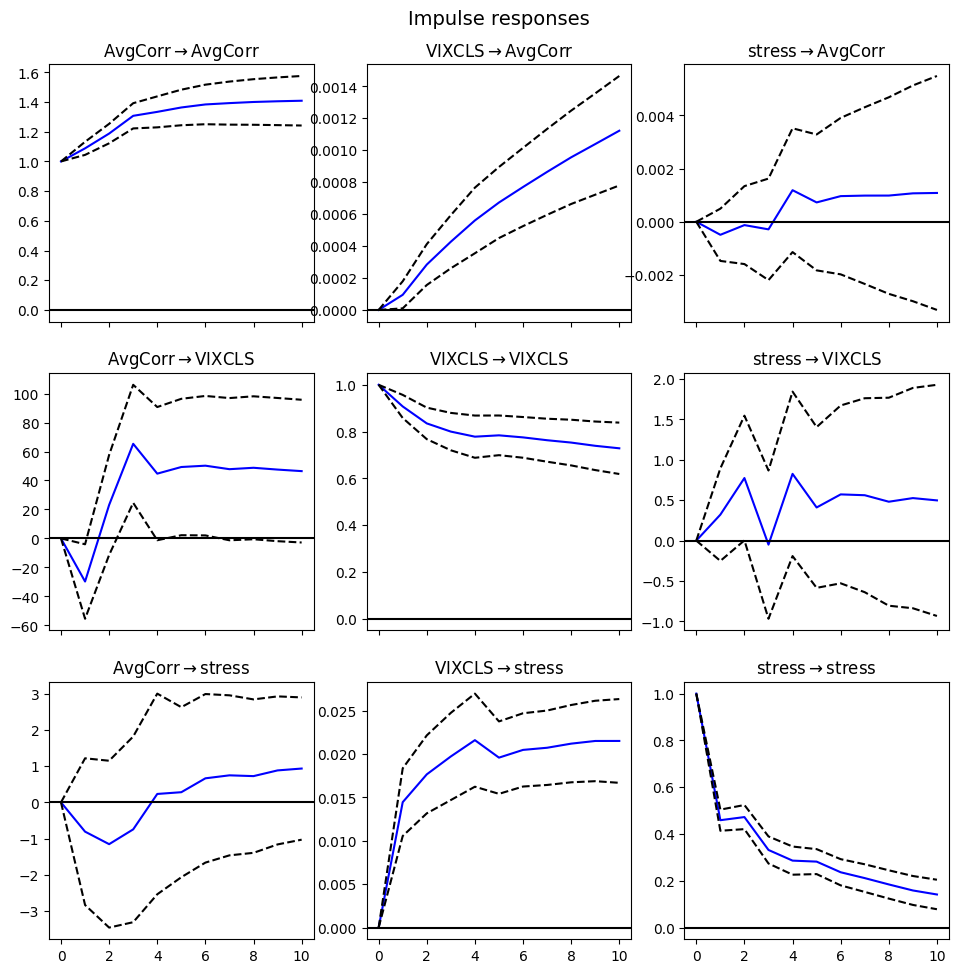

In [47]:
from statsmodels.tsa.api import VAR


var_data = df_analysis[['AvgCorr','VIXCLS','stress']].dropna()

# VAR Model
model = VAR(var_data)
results = model.fit(maxlags=5)

# Impulse Response
irf = results.irf(10)
irf.plot()

Using LagCorr


In [48]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# stress category
df_analysis['stress_bin'] = df_analysis['stress'].astype('category')

# LagCorr      
model = smf.ols('AvgCorr ~ stress_bin * VIXCLS + LagCorr', data=df_analysis).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                AvgCorr   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 3.616e+05
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        17:57:45   Log-Likelihood:                 9846.8
No. Observations:                2219   AIC:                        -1.968e+04
Df Residuals:                    2214   BIC:                        -1.966e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -0

VAR + Granger Causality + IRF


AvgCorr: ADF=-1.3875, p=0.5882
VIXCLS: ADF=-2.0995, p=0.2447
STLFSI: ADF=-2.8733, p=0.0485
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -4.846      -4.838    0.007862      -4.843
1       -17.75      -17.72   1.958e-08      -17.74
2       -17.78      -17.73   1.897e-08      -17.76
3       -17.79      -17.72   1.872e-08      -17.77
4       -17.82      -17.72   1.820e-08      -17.79
5       -17.87      -17.75   1.726e-08      -17.83
6       -17.94      -17.79   1.618e-08      -17.89
7       -17.99     -17.82*   1.544e-08      -17.92
8       -18.00      -17.80   1.527e-08      -17.93
9       -18.03      -17.81   1.478e-08     -17.95*
10     -18.04*      -17.80  1.467e-08*      -17.95
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 05, May, 2026
Time:                     17:57:46
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -17.7975
Nobs:                     2210.00    HQIC:                  -17.9497
Log likelihood:           10616.7    FPE:                1.46715e-08
AIC:                     -18.0374    Det(Omega_mle):     1.40710e-08
--------------------------------------------------------------------
Results for equation AvgCorr
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const              -0.001513         0.001098           -1.379           0.168
L1.AvgCorr          1.086655         0.022667           47.940           0.000
L1.VIXCLS           0.000071         0.000040            1.770    

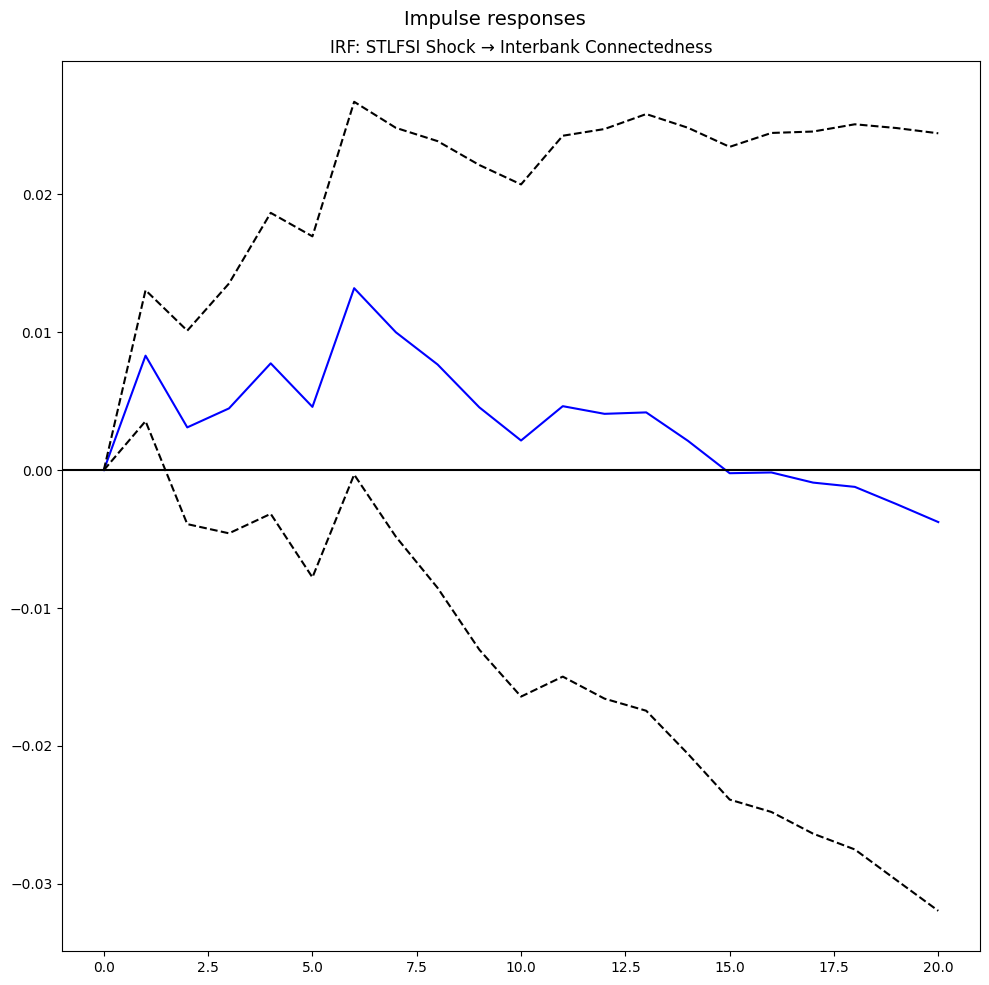

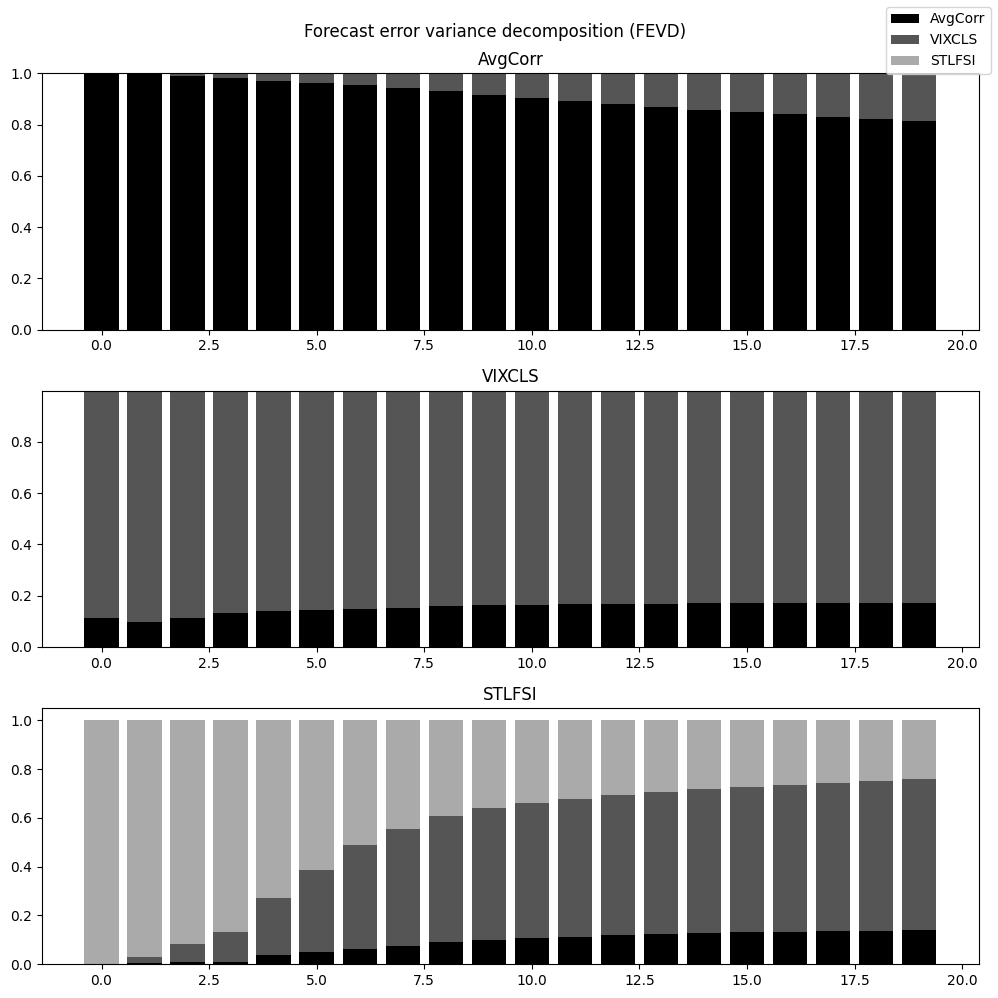

In [49]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

# Check stationarity first
for col in ['AvgCorr', 'VIXCLS', 'STLFSI']:
    adf = adfuller(df_analysis[col].dropna())
    print(f"{col}: ADF={adf[0]:.4f}, p={adf[1]:.4f}")

# VAR with optimal lag selection
var_data = df_analysis[['AvgCorr', 'VIXCLS', 'STLFSI']].dropna()
model = VAR(var_data)

# Select optimal lag order
lag_order = model.select_order(maxlags=10)
print(lag_order.summary())

results = model.fit(lag_order.aic)
print(results.summary())

# Granger Causality: Does stress Granger-cause connectedness?
gc_test = results.test_causality('AvgCorr', ['VIXCLS', 'STLFSI'], kind='f')
print(gc_test.summary())

# IRF with confidence bands
irf = results.irf(20)
irf.plot(impulse='STLFSI', response='AvgCorr')
plt.title('IRF: STLFSI Shock → Interbank Connectedness')
plt.tight_layout()
plt.show()

# Forecast Error Variance Decomposition
fevd = results.fevd(20)
fevd.plot()
plt.tight_layout()
plt.show()

DCC-GARCH


**Note:** The `arch` package is required for the GARCH extension. Install it with:
```bash
pip install arch
```


In [51]:
import sys
print(sys.executable)

/usr/bin/python3


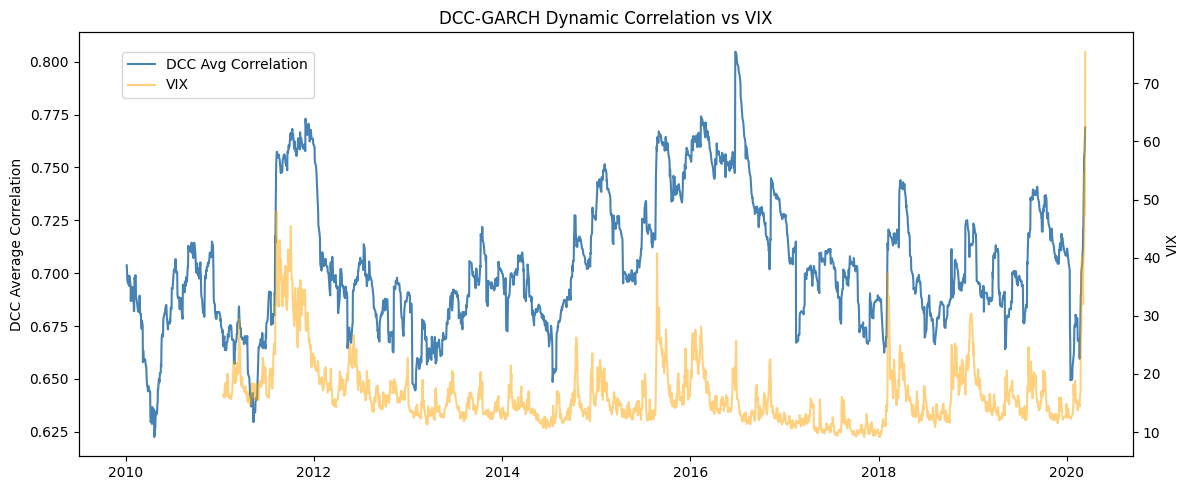

DCC Avg Corr - Calm:   0.7024
DCC Avg Corr - Stress: 0.746


In [52]:
from arch import arch_model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

banks = ["AIG","BAC","C","GS","JPM","MS","PNC","USB","WFC"]
returns = df[banks] * 100  # scale for GARCH convergence

# Step 1: Fit univariate GARCH(1,1) per bank, extract standardized residuals
std_resids = pd.DataFrame(index=returns.index, columns=banks)
cond_vols  = pd.DataFrame(index=returns.index, columns=banks)

for bank in banks:
    am = arch_model(returns[bank].dropna(), vol='Garch', p=1, q=1, dist='Normal')
    res = am.fit(disp='off')
    std_resids[bank] = res.std_resid
    cond_vols[bank]  = res.conditional_volatility

std_resids = std_resids.astype(float).dropna()

# Step 2: DCC estimation (Engle 2002 two-step approach)
# Unconditional correlation of standardized residuals
R_bar = std_resids.corr().values

n = len(banks)
T = len(std_resids)

# DCC parameters (a + b < 1 for stationarity; fix at standard values)
a, b = 0.01, 0.97

Q = R_bar.copy()
dcc_corr = []


for t in range(T):
    e = std_resids.iloc[t].values.reshape(-1, 1)
    Q = (1 - a - b) * R_bar + a * (e @ e.T) + b * Q
    # Normalize Q to correlation matrix
    D_inv = np.diag(1.0 / np.sqrt(np.diag(Q)))
    R_t = D_inv @ Q @ D_inv
    # Average off-diagonal correlation
    upper = R_t[np.triu_indices(n, k=1)]
    dcc_corr.append(upper.mean())

dcc_corr = pd.Series(dcc_corr, index=std_resids.index, name='DCC_AvgCorr')

# Plot DCC correlation vs VIX
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(dcc_corr.index, dcc_corr, label='DCC Avg Correlation', color='steelblue')
ax1.set_ylabel('DCC Average Correlation')

ax2 = ax1.twinx()
ax2.plot(df_analysis['VIXCLS'], label='VIX', color='orange', alpha=0.5)
ax2.set_ylabel('VIX')

fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.title('DCC-GARCH Dynamic Correlation vs VIX')
plt.tight_layout()
plt.show()

# Compare DCC correlation: stress vs calm periods
stress_mask = df_analysis['stress'].reindex(dcc_corr.index)
print("DCC Avg Corr - Calm:  ", dcc_corr[stress_mask==0].mean().round(4))
print("DCC Avg Corr - Stress:", dcc_corr[stress_mask==1].mean().round(4))

Diebold-Yilmaz Network Spillover Index


fevd.decomp shape: (9, 10, 9)
Total Spillover Index: 62.62%

Spillover Table:
              AIG     BAC      C     GS    JPM     MS    PNC    USB    WFC  \
AIG         98.38    0.34   0.63   0.04   0.00   0.02   0.02   0.50   0.05   
BAC         36.70   62.56   0.02   0.06   0.00   0.07   0.04   0.48   0.08   
C           40.85   32.67  25.51   0.01   0.02   0.01   0.06   0.60   0.27   
GS          32.32   27.21   4.93  34.59   0.00   0.00   0.13   0.52   0.29   
JPM         37.72   34.23   5.25   2.88  19.06   0.02   0.03   0.66   0.14   
MS          35.32   30.80   5.48   6.20   0.54  20.77   0.17   0.41   0.32   
PNC         35.99   26.38   2.44   1.16   3.31   0.18  30.01   0.49   0.04   
USB         37.42   25.52   3.13   1.31   2.98   0.05   6.15  23.36   0.08   
WFC         39.30   23.37   3.42   1.16   2.57   0.07   4.05   3.86  22.20   
TO_others  295.63  200.53  25.29  12.83   9.42   0.42  10.64   7.52   1.26   
NET        294.01  163.09 -49.20 -52.58 -71.51 -78.81 -59.34 -69

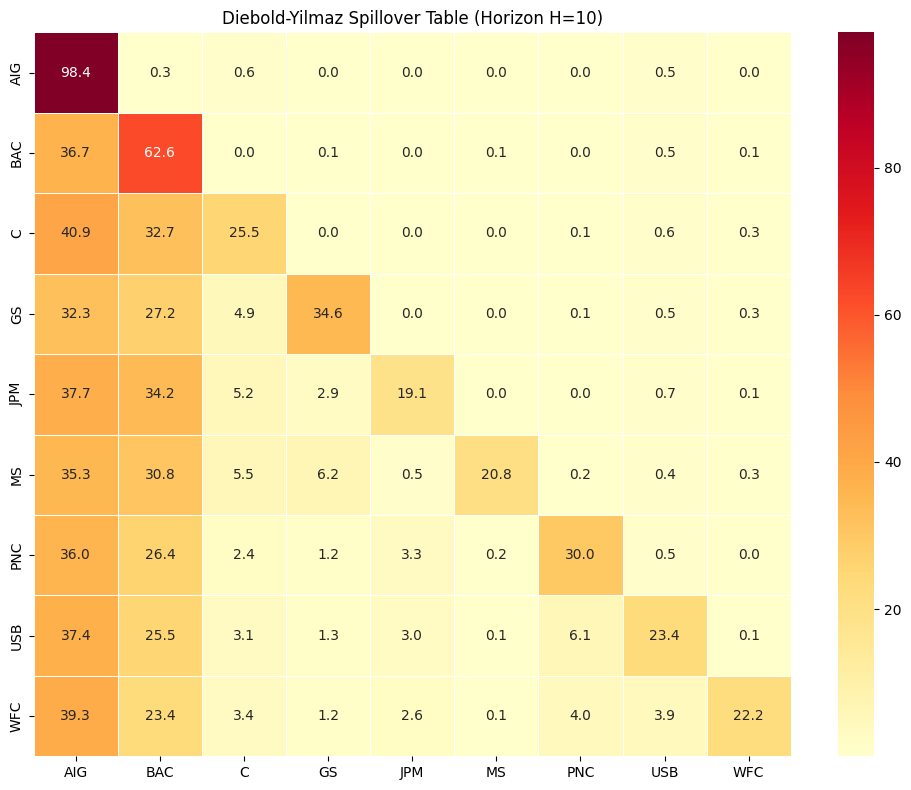

Failed at 2011-01-14 00:00:00: name 'extract_fevd_matrix' is not defined
Failed at 2011-01-19 00:00:00: name 'extract_fevd_matrix' is not defined
Failed at 2011-01-20 00:00:00: name 'extract_fevd_matrix' is not defined
Failed at 2011-01-21 00:00:00: name 'extract_fevd_matrix' is not defined
Failed at 2011-01-24 00:00:00: name 'extract_fevd_matrix' is not defined
Failed at 2011-01-25 00:00:00: name 'extract_fevd_matrix' is not defined
Failed at 2011-01-26 00:00:00: name 'extract_fevd_matrix' is not defined
Failed at 2011-01-27 00:00:00: name 'extract_fevd_matrix' is not defined
Failed at 2011-01-28 00:00:00: name 'extract_fevd_matrix' is not defined
Failed at 2011-01-31 00:00:00: name 'extract_fevd_matrix' is not defined
Failed at 2011-02-01 00:00:00: name 'extract_fevd_matrix' is not defined
Failed at 2011-02-02 00:00:00: name 'extract_fevd_matrix' is not defined
Failed at 2011-02-03 00:00:00: name 'extract_fevd_matrix' is not defined
Failed at 2011-02-04 00:00:00: name 'extract_fevd_m

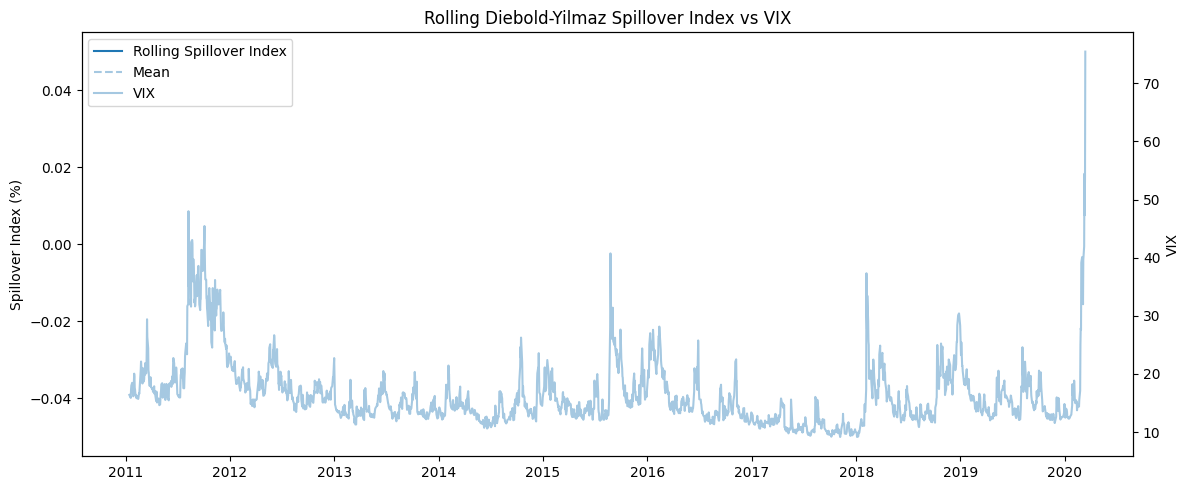

In [53]:
from statsmodels.tsa.api import VAR
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

banks = ["AIG","BAC","C","GS","JPM","MS","PNC","USB","WFC"]
ret_data = df[banks].dropna()

# Fit VAR on full sample
var_model = VAR(ret_data)
var_fit = var_model.fit(maxlags=5, ic='aic')

H = 10  # forecast horizon for FEVD
fevd = var_fit.fevd(H)

# Build spillover table
# fevd_mat[i, j] = % of bank i's forecast error variance explained by bank j's shock
fevd_array = np.array(fevd.decomp)  # shape could be (n, n, H) or (H, n, n) depending on version
print("fevd.decomp shape:", fevd_array.shape)  # check first

# Shape is (n_vars, H, n_vars): axis0=responding var, axis1=horizon, axis2=impulse var
# Take horizon H-1 slice → result shape (n_vars, n_vars)
fevd_mat = fevd_array[:, H-1, :]

fevd_df = pd.DataFrame(fevd_mat * 100, index=banks, columns=banks)

# Total Spillover Index
n = len(banks)
off_diag_sum = fevd_df.values.sum() - np.trace(fevd_df.values)
total_spillover = off_diag_sum / fevd_df.values.sum() * 100
print(f"Total Spillover Index: {total_spillover:.2f}%")

# Directional spillovers: FROM and TO others, NET
core = fevd_df.iloc[:n, :n]  # always work on the 9x9 core

fevd_df['FROM_others'] = core.sum(axis=1) - np.diag(core.values)
fevd_df.loc['TO_others'] = core.sum(axis=0) - np.diag(core.values)
fevd_df.loc['NET'] = fevd_df.loc['TO_others'] - fevd_df['FROM_others']

print("\nSpillover Table:")
print(fevd_df.round(2))

# Heatmap of pairwise spillovers (core banks only, no summary rows)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    fevd_df.iloc[:n, :n], annot=True, fmt='.1f',
    cmap='YlOrRd', ax=ax, linewidths=0.5
)
ax.set_title(f'Diebold-Yilmaz Spillover Table (Horizon H={H})')
plt.tight_layout()
plt.show()

# Rolling spillover
window = 252
rolling_spillover = []
rolling_dates = []
error_count = 0

for i in range(window, len(ret_data)):
    sub = ret_data.iloc[i-window:i]
    try:
        vm = VAR(sub)
        vf = vm.fit(1)   # fixed lag
        fd = extract_fevd_matrix(vf.fevd(H), H, n)

        off = fd.sum() - np.trace(fd)
        tsi = off / fd.sum() * 100

        rolling_spillover.append(tsi)
        rolling_dates.append(ret_data.index[i])

    except Exception as e:
        error_count += 1
        print(f"Failed at {ret_data.index[i]}: {e}")
        rolling_spillover.append(np.nan)
        rolling_dates.append(ret_data.index[i])

roll_spill = pd.Series(rolling_spillover, index=rolling_dates)

print("Total rolling points:", len(roll_spill))
print("Non-missing points:", roll_spill.notna().sum())
print("Missing points:", roll_spill.isna().sum())
print("Errors:", error_count)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(roll_spill.index, roll_spill, label='Rolling Spillover Index')
ax1.set_ylabel('Spillover Index (%)')
ax1.axhline(roll_spill.mean(), linestyle='--', alpha=0.4, label='Mean')

ax2 = ax1.twinx()
ax2.plot(df['VIXCLS'].reindex(roll_spill.index), alpha=0.4, label='VIX')
ax2.set_ylabel('VIX')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Rolling Diebold-Yilmaz Spillover Index vs VIX')
plt.tight_layout()
plt.show()

(iv) Model Validation
Model 1: AvgCorr ~ VIXCLS + Stress
Model 2: AvgCorr ~ Stress + LagCorr


Fold-level validation results:


,Fold,Train_End,Test_Start,Test_End,RMSE_Model1,MAE_Model1,StressCoef_Model1,StressPval_Model1,RMSE_Model2,MAE_Model2,StressCoef_Model2,StressPval_Model2
0,1,2017-06-13,2017-06-14,2017-07-27,0.057740,0.050853,0.045347,9.308692e-47,0.005653,0.002027,0.000379,2.284087e-07
1,2,2017-07-27,2017-07-28,2017-09-11,0.021573,0.020034,0.043921,3.343493e-45,0.001585,0.001082,0.000420,1.326962e-08
2,3,2017-09-11,2017-09-12,2017-10-23,0.013578,0.012895,0.043177,1.001250e-45,0.001511,0.001109,0.000405,1.849138e-08
3,4,2017-10-23,2017-10-24,2017-12-06,0.013902,0.011363,0.042884,1.716781e-46,0.004137,0.002138,0.000405,8.124107e-09
4,5,2017-12-06,2017-12-07,2018-01-25,0.046462,0.045947,0.042916,1.536627e-48,0.001486,0.001096,0.000427,9.182557e-10
5,6,2018-01-25,2018-01-26,2018-03-12,0.034062,0.029099,0.043857,1.340232e-51,0.006831,0.003486,0.000430,3.664594e-10
6,7,2018-03-12,2018-03-13,2018-04-25,0.014520,0.012979,0.043527,1.776977e-55,0.002920,0.001971,0.000414,6.529845e-09
7,8,2018-04-25,2018-04-26,2018-06-08,0.028725,0.027292,0.043472,1.472042e-56,0.001746,0.001164,0.000416,5.406203e-09
8,9,2018-06-08,2018-06-11,2018-07-24,0.033337,0.032718,0.043170,7.835747e-57,0.001526,0.001023,0.000415,4.816127e-09
9,10,2018-07-24,2018-07-25,2018-09-06,0.026531,0.025334,0.043007,2.691765e-57,0.001092,0.000755,0.000416,3.599393e-09



Overall validation summary:


,Model,Mean_RMSE,Mean_MAE,Mean_Stress_Coef,SD_Stress_Coef,Pct_Stress_p_lt_0.05
0,Model 1: AvgCorr ~ VIXCLS + Stress,0.031695,0.029589,0.043453,0.000736,1.0
1,Model 2: AvgCorr ~ Stress + LagCorr,0.002696,0.001635,0.000408,0.000014,1.0


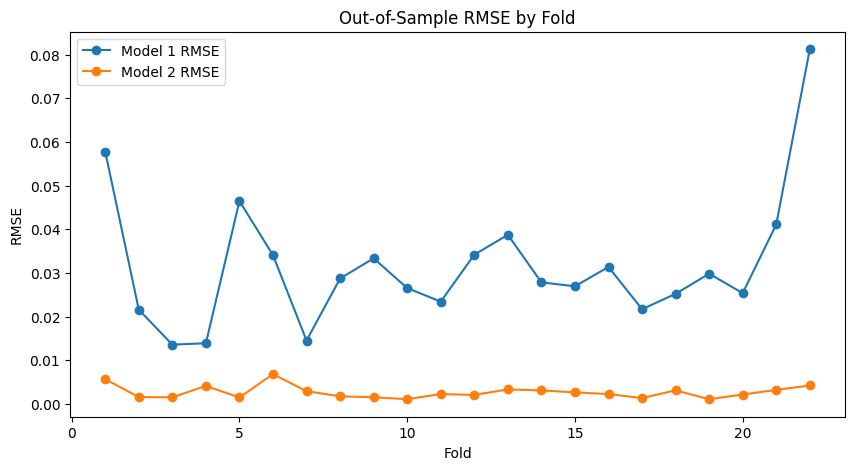

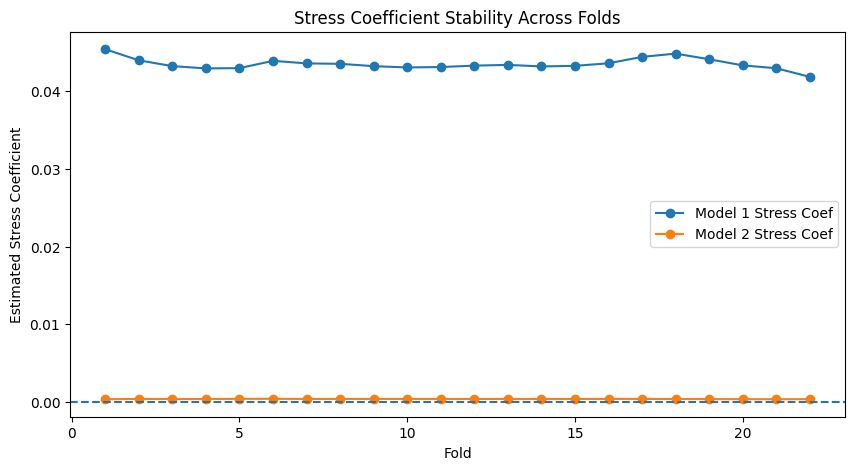

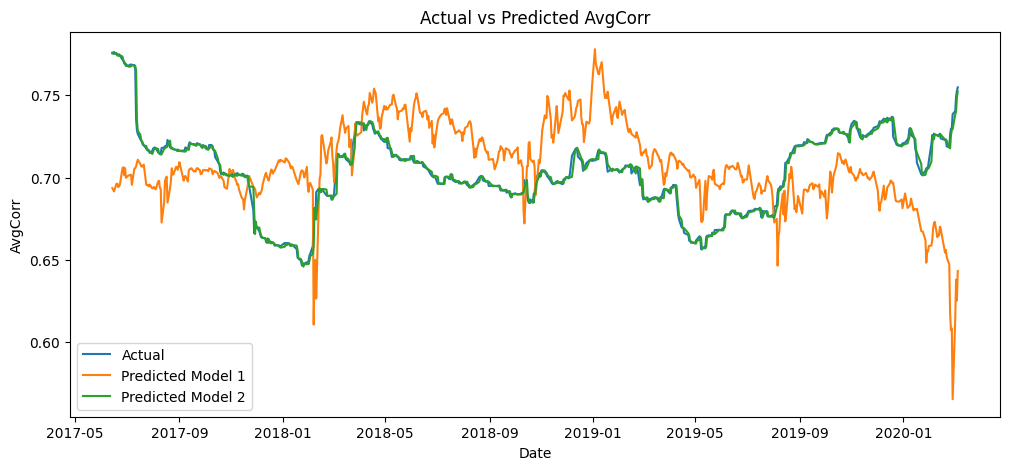

In [54]:

import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

df_val = df_analysis.copy()

df_val["LagCorr"] = df_val["AvgCorr"].shift(1)

df_val = df_val[["AvgCorr", "VIXCLS", "Stress", "LagCorr"]].dropna().copy()

# initial training size = first 70%
initial_train_size = int(len(df_val) * 0.7)

test_size = 30

results = []
predictions = []


fold = 1
start_test = initial_train_size

while start_test + test_size <= len(df_val):

    train = df_val.iloc[:start_test].copy()
    test = df_val.iloc[start_test:start_test + test_size].copy()

    # Model 1: AvgCorr ~ VIXCLS + Stress
    X_train_1 = sm.add_constant(train[["VIXCLS", "Stress"]])
    y_train = train["AvgCorr"]

    X_test_1 = sm.add_constant(test[["VIXCLS", "Stress"]], has_constant="add")
    y_test = test["AvgCorr"]

    model1 = sm.OLS(y_train, X_train_1).fit()
    pred1 = model1.predict(X_test_1)

    rmse1 = np.sqrt(mean_squared_error(y_test, pred1))
    mae1 = mean_absolute_error(y_test, pred1)

    # Model 2: AvgCorr ~ Stress + LagCorr
    X_train_2 = sm.add_constant(train[["Stress", "LagCorr"]])
    X_test_2  = sm.add_constant(test[["Stress", "LagCorr"]], has_constant="add")

    model2 = sm.OLS(y_train, X_train_2).fit()
    pred2 = model2.predict(X_test_2)

    rmse2 = np.sqrt(mean_squared_error(y_test, pred2))
    mae2 = mean_absolute_error(y_test, pred2)

    results.append({
        "Fold": fold,
        "Train_End": train.index[-1],
        "Test_Start": test.index[0],
        "Test_End": test.index[-1],

        "RMSE_Model1": rmse1,
        "MAE_Model1": mae1,
        "StressCoef_Model1": model1.params["Stress"],
        "StressPval_Model1": model1.pvalues["Stress"],

        "RMSE_Model2": rmse2,
        "MAE_Model2": mae2,
        "StressCoef_Model2": model2.params["Stress"],
        "StressPval_Model2": model2.pvalues["Stress"]
    })

    fold_pred = pd.DataFrame({
        "Date": test.index,
        "Actual": y_test.values,
        "Pred_Model1": pred1.values,
        "Pred_Model2": pred2.values,
        "Fold": fold
    })
    predictions.append(fold_pred)

    start_test += test_size
    fold += 1

# Summarize results
results_df = pd.DataFrame(results)
pred_df = pd.concat(predictions, ignore_index=True)

print("Fold-level validation results:")
display(results_df)

summary_table = pd.DataFrame({
    "Model": ["Model 1: AvgCorr ~ VIXCLS + Stress",
              "Model 2: AvgCorr ~ Stress + LagCorr"],
    "Mean_RMSE": [results_df["RMSE_Model1"].mean(), results_df["RMSE_Model2"].mean()],
    "Mean_MAE":  [results_df["MAE_Model1"].mean(),  results_df["MAE_Model2"].mean()],
    "Mean_Stress_Coef": [results_df["StressCoef_Model1"].mean(),
                         results_df["StressCoef_Model2"].mean()],
    "SD_Stress_Coef": [results_df["StressCoef_Model1"].std(),
                       results_df["StressCoef_Model2"].std()],
    "Pct_Stress_p_lt_0.05": [
        (results_df["StressPval_Model1"] < 0.05).mean(),
        (results_df["StressPval_Model2"] < 0.05).mean()
    ]
})

print("\nOverall validation summary:")
display(summary_table)

# Plot RMSE by fold
plt.figure(figsize=(10, 5))
plt.plot(results_df["Fold"], results_df["RMSE_Model1"], marker="o", label="Model 1 RMSE")
plt.plot(results_df["Fold"], results_df["RMSE_Model2"], marker="o", label="Model 2 RMSE")
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.title("Out-of-Sample RMSE by Fold")
plt.legend()
plt.show()

# Plot stress coefficient stability
plt.figure(figsize=(10, 5))
plt.plot(results_df["Fold"], results_df["StressCoef_Model1"], marker="o", label="Model 1 Stress Coef")
plt.plot(results_df["Fold"], results_df["StressCoef_Model2"], marker="o", label="Model 2 Stress Coef")
plt.axhline(0, linestyle="--")
plt.xlabel("Fold")
plt.ylabel("Estimated Stress Coefficient")
plt.title("Stress Coefficient Stability Across Folds")
plt.legend()
plt.show()

# Step 6: Plot actual vs predicted
plt.figure(figsize=(12, 5))
plt.plot(pred_df["Date"], pred_df["Actual"], label="Actual")
plt.plot(pred_df["Date"], pred_df["Pred_Model1"], label="Predicted Model 1")
plt.plot(pred_df["Date"], pred_df["Pred_Model2"], label="Predicted Model 2")
plt.xlabel("Date")
plt.ylabel("AvgCorr")
plt.title("Actual vs Predicted AvgCorr")
plt.legend()
plt.show()

Kyle new version (4/23)


In [55]:
import pandas as pd
import numpy as np

import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

Model 1 AvgCorr∼STLFSI+stress ('stress' is a binary variable based on 90% quantile for VIXCLS)


In [56]:
df = df_analysis.copy()

y = df['AvgCorr']
X = df[['STLFSI', 'stress']]
X = sm.add_constant(X)

In [57]:
model1 = sm.OLS(y, X).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                AvgCorr   R-squared:                       0.128
Model:                            OLS   Adj. R-squared:                  0.128
Method:                 Least Squares   F-statistic:                     163.3
Date:                Tue, 05 May 2026   Prob (F-statistic):           7.02e-67
Time:                        17:58:27   Log-Likelihood:                 2806.8
No. Observations:                2220   AIC:                            -5608.
Df Residuals:                    2217   BIC:                            -5590.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8212      0.006    139.508      0.0

not a great model


In [58]:
residuals = model1.resid
fitted = model1.fittedvalues

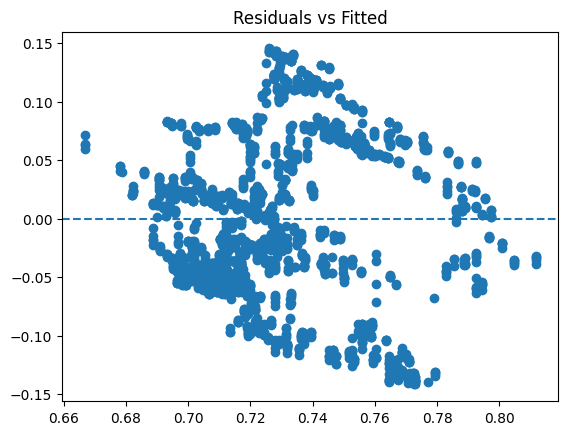

In [59]:
import matplotlib.pyplot as plt

plt.scatter(fitted, residuals)
plt.axhline(0, linestyle='--')
plt.title("Residuals vs Fitted")
plt.show()

In [60]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(residuals, model1.model.exog)
print("BP test p-value:", bp_test[1])

BP test p-value: 4.372780125815457e-76


In [61]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(residuals)
print("Durbin-Watson:", dw)

Durbin-Watson: 0.004205335266954851


In [62]:
from scipy import stats

jb = stats.jarque_bera(residuals)
print("JB p-value:", jb[1])

JB p-value: 7.437135301861948e-12


heteroskedasticity


In [63]:
vif = pd.DataFrame()
vif["variable"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)

  variable        VIF
0    const  16.448488
1   STLFSI   1.316502
2   stress   1.316502


In [64]:
scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(df[['VIXCLS', 'STLFSI']]),
    index=df.index,
    columns=['VIXCLS', 'STLFSI']
)

X_scaled = sm.add_constant(X_scaled)

model_scaled = sm.OLS(y, X_scaled).fit()

beta1 = beta2


In [65]:
model_scaled.t_test("VIXCLS = STLFSI")

<class 'statsmodels.stats.contrast.ContrastResults'>
                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.0423      0.004    -11.909      0.000      -0.049      -0.035

their effects are not the same (they should be included together)


Model2 (Interaction model) AvgCorr∼STLFSI+stress+STLFSI×stress


In [66]:
df['interaction'] = df['STLFSI'] * df['stress']

X2 = df[['STLFSI','stress','interaction']]
X2 = sm.add_constant(X2)

model2 = sm.OLS(y, X2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                AvgCorr   R-squared:                       0.135
Model:                            OLS   Adj. R-squared:                  0.134
Method:                 Least Squares   F-statistic:                     115.7
Date:                Tue, 05 May 2026   Prob (F-statistic):           1.30e-69
Time:                        17:58:28   Log-Likelihood:                 2815.8
No. Observations:                2220   AIC:                            -5624.
Df Residuals:                    2216   BIC:                            -5601.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.8317      0.006    130.815      

In [67]:
bp2 = het_breuschpagan(model2.resid, model2.model.exog)
print("BP p-value (Interaction):", bp2[1])

BP p-value (Interaction): 1.1161151722746995e-100


again it doesn't work for assumption


Model3 AvgCorr∼STLFSI+stress+LagCorr


In [68]:
df['LagCorr'] = df['AvgCorr'].shift(1)

df_lag = df.dropna().copy()

y_lag = df_lag['AvgCorr']
X3 = df_lag[['STLFSI','stress','LagCorr']]
X3 = sm.add_constant(X3)

model3 = sm.OLS(y_lag, X3).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                AvgCorr   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 4.129e+05
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        17:58:28   Log-Likelihood:                 9466.6
No. Observations:                2161   AIC:                        -1.893e+04
Df Residuals:                    2157   BIC:                        -1.890e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.001      0.932      0.3

not a great model


In [69]:
bp3 = het_breuschpagan(model3.resid, model3.model.exog)
print("BP p-value (Lag model):", bp3[1])

BP p-value (Lag model): 8.233321289815576e-12


heteroskedasticity


ANOVA Table (justifying model2/3 are better than model1)


In [70]:
anova_results = anova_lm(model1, model2)
print(anova_results)

   df_resid        ssr  df_diff   ss_diff          F    Pr(>F)
0    2217.0  10.368448      0.0       NaN        NaN       NaN
1    2216.0  10.284651      1.0  0.083797  18.055428  0.000022


In [71]:
anova_results = anova_lm(model1, model3)
print(anova_results)

   df_resid        ssr  df_diff    ss_diff             F  Pr(>F)
0    2217.0  10.368448      0.0        NaN           NaN     NaN
1    2157.0   0.019824     60.0  10.348623  18766.666606     0.0


ANCOVA (can not justify including market factor)


In [72]:
# Model with market
X_mkt = sm.add_constant(df[['STLFSI','stress','MKT']])
model_mkt = sm.OLS(y, X_mkt).fit()

# Model without market
X_nomkt = sm.add_constant(df[['STLFSI','stress']])
model_nomkt = sm.OLS(y, X_nomkt).fit()

anova_market = anova_lm(model_nomkt, model_mkt)
print(anova_market)

   df_resid        ssr  df_diff   ss_diff         F    Pr(>F)
0    2217.0  10.368448      0.0       NaN       NaN       NaN
1    2216.0  10.368401      1.0  0.000046  0.009912  0.920702


Train/Test split (for RMSE)


In [73]:
split = int(len(df) * 0.8)

train = df.iloc[:split].dropna()
test = df.iloc[split:]

Model1 RMSE


In [74]:
X_train1 = sm.add_constant(train[['STLFSI','stress']])
X_test1 = sm.add_constant(test[['STLFSI','stress']])

m1 = sm.OLS(train['AvgCorr'], X_train1).fit()
pred1 = m1.predict(X_test1)

rmse1 = np.sqrt(mean_squared_error(test['AvgCorr'], pred1))
print("OLS RMSE:", rmse1)

OLS RMSE: 0.040243798594403336


Model2 RMSE (Interaction)


In [75]:
train2 = train.copy()
test2 = test.copy()

train2['interaction'] = train2['STLFSI'] * train2['stress']
test2['interaction'] = test2['STLFSI'] * test2['stress']

X_train2 = sm.add_constant(train2[['STLFSI','stress','interaction']])
X_test2 = sm.add_constant(test2[['STLFSI','stress','interaction']])

m2 = sm.OLS(train2['AvgCorr'], X_train2).fit()
pred2 = m2.predict(X_test2)

rmse2 = np.sqrt(mean_squared_error(test2['AvgCorr'], pred2))
print("Interaction RMSE:", rmse2)

Interaction RMSE: 0.037703794895545456


Model3 RMSE (Lag model)


In [76]:
train3 = train.dropna().copy()
test3 = test.copy()

train3['LagCorr'] = train3['AvgCorr'].shift(1)
train3 = train3.dropna()

test3['LagCorr'] = test3['AvgCorr'].shift(1)
test3 = test3.dropna()

X_train3 = sm.add_constant(train3[['STLFSI','stress','LagCorr']])
X_test3 = sm.add_constant(test3[['STLFSI','stress','LagCorr']])

m3 = sm.OLS(train3['AvgCorr'], X_train3).fit()
pred3 = m3.predict(X_test3)

rmse3 = np.sqrt(mean_squared_error(test3['AvgCorr'], pred3))
print("Lag RMSE:", rmse3)

Lag RMSE: 0.003558146183832401


DCC-GARCH (final model step)


Additional Model Diagnostics
The previous OLS models show evidence of heteroskedasticity based on the Breusch-Pagan test. In addition, the Durbin-Watson statistics for the baseline and interaction models are close to zero, suggesting strong positive serial correlation in the residuals.
Therefore, the usual OLS standard errors may not be reliable. To address this issue, we re-estimate the main OLS specifications using HAC/Newey-West robust standard errors, which are robust to both heteroskedasticity and autocorrelation.


In [77]:
# Re-estimate OLS models with HAC / Newey-West robust standard errors

model1_hac = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 20})
print("Model 1 with HAC standard errors")
print(model1_hac.summary())

model2_hac = sm.OLS(y, X2).fit(cov_type='HAC', cov_kwds={'maxlags': 20})
print("Model 2 Interaction with HAC standard errors")
print(model2_hac.summary())

model3_hac = sm.OLS(y_lag, X3).fit(cov_type='HAC', cov_kwds={'maxlags': 20})
print("Model 3 Lag Model with HAC standard errors")
print(model3_hac.summary())

Model 1 with HAC standard errors
                            OLS Regression Results                            
Dep. Variable:                AvgCorr   R-squared:                       0.128
Model:                            OLS   Adj. R-squared:                  0.128
Method:                 Least Squares   F-statistic:                     12.78
Date:                Tue, 05 May 2026   Prob (F-statistic):           3.02e-06
Time:                        17:58:29   Log-Likelihood:                 2806.8
No. Observations:                2220   AIC:                            -5608.
Df Residuals:                    2217   BIC:                            -5590.
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.82

revision: ANOVA Comparison for the Lag Model
The previous ANOVA comparison between Model 1 and Model 3 is not valid because the two models were estimated on different sample sizes after introducing the lagged dependent variable. Since ANOVA model comparison requires the models to be estimated on the same observations, we reconstruct Model 1 and Model 3 using a common sample.


In [78]:
# Correct ANOVA comparison using the same sample

df_common = df.copy()
df_common['LagCorr'] = df_common['AvgCorr'].shift(1)
df_common = df_common.dropna()

y_common = df_common['AvgCorr']

X1_common = sm.add_constant(df_common[['STLFSI', 'stress']])
X3_common = sm.add_constant(df_common[['STLFSI', 'stress', 'LagCorr']])

model1_common = sm.OLS(y_common, X1_common).fit()
model3_common = sm.OLS(y_common, X3_common).fit()

anova_lag_corrected = anova_lm(model1_common, model3_common)
print(anova_lag_corrected)

   df_resid       ssr  df_diff   ss_diff             F  Pr(>F)
0    2158.0  9.225716      0.0       NaN           NaN     NaN
1    2157.0  0.019824      1.0  9.205892  1.001663e+06     0.0


Expanding-Window Time-Series Cross-Validation
A single 80/20 train-test split may be sensitive to the specific split point. Since the data are time series, we use an expanding-window cross-validation approach. In each fold, the model is trained using past observations and tested on future observations. This preserves the time ordering of the data and provides a more robust out-of-sample comparison.


In [79]:
# Expanding-window cross-validation for Model 1, Model 2, and Model 3

df_cv = df.copy()
df_cv['LagCorr'] = df_cv['AvgCorr'].shift(1)
df_cv['interaction'] = df_cv['STLFSI'] * df_cv['stress']
df_cv = df_cv.dropna()

initial_train_size = int(len(df_cv) * 0.5)
test_size = 50

cv_results = []

for start in range(initial_train_size, len(df_cv) - test_size, test_size):
    train_cv = df_cv.iloc[:start]
    test_cv = df_cv.iloc[start:start + test_size]

    y_train = train_cv['AvgCorr']
    y_test = test_cv['AvgCorr']

    # Model 1: STLFSI + stress
    X_train1 = sm.add_constant(train_cv[['STLFSI', 'stress']])
    X_test1 = sm.add_constant(test_cv[['STLFSI', 'stress']])
    m1_cv = sm.OLS(y_train, X_train1).fit()
    pred1 = m1_cv.predict(X_test1)

    # Model 2: STLFSI + stress + interaction
    X_train2 = sm.add_constant(train_cv[['STLFSI', 'stress', 'interaction']])
    X_test2 = sm.add_constant(test_cv[['STLFSI', 'stress', 'interaction']])
    m2_cv = sm.OLS(y_train, X_train2).fit()
    pred2 = m2_cv.predict(X_test2)

    # Model 3: STLFSI + stress + LagCorr
    X_train3 = sm.add_constant(train_cv[['STLFSI', 'stress', 'LagCorr']])
    X_test3 = sm.add_constant(test_cv[['STLFSI', 'stress', 'LagCorr']])
    m3_cv = sm.OLS(y_train, X_train3).fit()
    pred3 = m3_cv.predict(X_test3)

    cv_results.append({
        'fold': len(cv_results) + 1,
        'RMSE_Model1_Baseline': np.sqrt(mean_squared_error(y_test, pred1)),
        'RMSE_Model2_Interaction': np.sqrt(mean_squared_error(y_test, pred2)),
        'RMSE_Model3_Lag': np.sqrt(mean_squared_error(y_test, pred3))
    })

cv_results = pd.DataFrame(cv_results)

print(cv_results)
print("\nAverage RMSE by model:")
print(cv_results.drop(columns='fold').mean())

    fold  RMSE_Model1_Baseline  RMSE_Model2_Interaction  RMSE_Model3_Lag
0      1              0.095931                 0.090938         0.001853
1      2              0.070516                 0.059114         0.001824
2      3              0.100512                 0.096093         0.001262
3      4              0.137027                 0.134223         0.001264
4      5              0.142090                 0.142513         0.001197
5      6              0.120154                 0.120177         0.000933
6      7              0.101781                 0.102656         0.002910
7      8              0.085751                 0.090088         0.001307
8      9              0.077551                 0.084303         0.004504
9     10              0.027488                 0.033090         0.001490
10    11              0.021062                 0.021332         0.003376
11    12              0.038573                 0.050732         0.005237
12    13              0.028746                 0.03

RMSE Comparison across Cross-Validation Folds
The following plot compares the out-of-sample RMSE of the three model specifications across cross-validation folds.


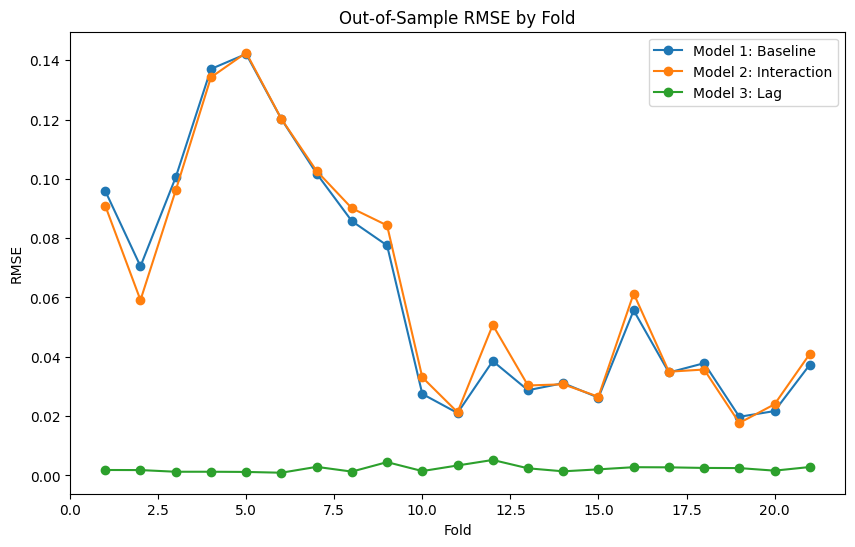

In [80]:
plt.figure(figsize=(10, 6))

plt.plot(cv_results['fold'], cv_results['RMSE_Model1_Baseline'], marker='o', label='Model 1: Baseline')
plt.plot(cv_results['fold'], cv_results['RMSE_Model2_Interaction'], marker='o', label='Model 2: Interaction')
plt.plot(cv_results['fold'], cv_results['RMSE_Model3_Lag'], marker='o', label='Model 3: Lag')

plt.xlabel('Fold')
plt.ylabel('RMSE')
plt.title('Out-of-Sample RMSE by Fold')
plt.legend()
plt.show()

Next we will check if we can use DCC-GARCH


Does stress add explanatory power beyond persistence?
Since the lag model performs significantly better, we test whether financial stress variables still contribute after controlling for persistence.
We compare a lag-only model with a lag-plus-stress model.


In [81]:
# Lag-only vs Lag + stress (same sample)

X_lag_only = sm.add_constant(df_common[['LagCorr']])
X_lag_full = sm.add_constant(df_common[['LagCorr', 'STLFSI', 'stress']])

m_lag_only = sm.OLS(y_common, X_lag_only).fit(cov_type='HAC', cov_kwds={'maxlags':20})
m_lag_full = sm.OLS(y_common, X_lag_full).fit(cov_type='HAC', cov_kwds={'maxlags':20})

print("Lag-only model:")
print(m_lag_only.summary())

print("\nLag + stress model:")
print(m_lag_full.summary())

print("\nANOVA comparison:")
m_lag_only_ols = sm.OLS(y_common, X_lag_only).fit()
m_lag_full_ols = sm.OLS(y_common, X_lag_full).fit()
print(anova_lm(m_lag_only_ols, m_lag_full_ols))

Lag-only model:
                            OLS Regression Results                            
Dep. Variable:                AvgCorr   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 7.735e+05
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        17:58:30   Log-Likelihood:                 9407.3
No. Observations:                2161   AIC:                        -1.881e+04
Df Residuals:                    2159   BIC:                        -1.880e+04
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.001    

### Out-of-sample comparison: Lag-only vs Lag + stress


In [82]:
lag_compare_results = []

for start in range(initial_train_size, len(df_cv) - test_size, test_size):
    train_cv = df_cv.iloc[:start]
    test_cv = df_cv.iloc[start:start + test_size]

    y_train = train_cv['AvgCorr']
    y_test = test_cv['AvgCorr']

    # Lag only
    X_train_lag = sm.add_constant(train_cv[['LagCorr']])
    X_test_lag = sm.add_constant(test_cv[['LagCorr']])
    m_lag = sm.OLS(y_train, X_train_lag).fit()
    pred_lag = m_lag.predict(X_test_lag)

    # Lag + stress
    X_train_full = sm.add_constant(train_cv[['LagCorr','STLFSI','stress']])
    X_test_full = sm.add_constant(test_cv[['LagCorr','STLFSI','stress']])
    m_full = sm.OLS(y_train, X_train_full).fit()
    pred_full = m_full.predict(X_test_full)

    lag_compare_results.append({
        'RMSE_Lag_Only': np.sqrt(mean_squared_error(y_test, pred_lag)),
        'RMSE_Lag_Stress': np.sqrt(mean_squared_error(y_test, pred_full))
    })

lag_compare_results = pd.DataFrame(lag_compare_results)

print(lag_compare_results)
print("\nAverage RMSE:")
print(lag_compare_results.mean())

    RMSE_Lag_Only  RMSE_Lag_Stress
0        0.001810         0.001853
1        0.001692         0.001824
2        0.001088         0.001262
3        0.001365         0.001264
4        0.001309         0.001197
5        0.000933         0.000933
6        0.003010         0.002910
7        0.001359         0.001307
8        0.004578         0.004504
9        0.001507         0.001490
10       0.003464         0.003376
11       0.005373         0.005237
12       0.002524         0.002422
13       0.001435         0.001404
14       0.002221         0.002070
15       0.002607         0.002797
16       0.002764         0.002747
17       0.002572         0.002547
18       0.002520         0.002494
19       0.001591         0.001630
20       0.002899         0.002857

Average RMSE:
RMSE_Lag_Only      0.002315
RMSE_Lag_Stress    0.002292
dtype: float64


### Simple GARCH Extension
Since the OLS diagnostics show heteroskedasticity, we further explore whether the volatility of AvgCorr is time-varying. As a simple extension, we fit a GARCH(1,1) model to AvgCorr.
This does not replace the previous regression models. Instead, it helps check whether the variance of interbank connectedness changes over time.


**Note:** The `arch` package is required for the GARCH extension. Install it with:
```bash
pip install arch
```


In [84]:
from arch import arch_model

# GARCH models often work better when the variable is scaled
avgcorr_scaled = df_common['AvgCorr'] * 100

garch_model = arch_model(
    avgcorr_scaled,
    mean='Constant',
    vol='GARCH',
    p=1,
    q=1,
    dist='normal'
)

garch_result = garch_model.fit(disp='off')

print(garch_result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                AvgCorr   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6197.47
Distribution:                  Normal   AIC:                           12402.9
Method:            Maximum Likelihood   BIC:                           12425.7
                                        No. Observations:                 2161
Date:                Tue, May 05 2026   Df Residuals:                     2160
Time:                        17:58:40   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu            70.3127  8.634e-02    814.404      0.000 [ 70.143, 70.48

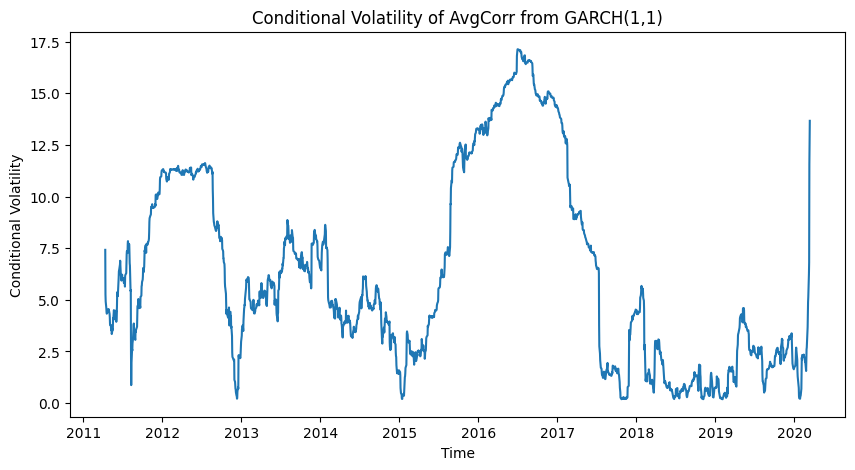

In [85]:
# Plot conditional volatility from GARCH model

conditional_vol = garch_result.conditional_volatility

plt.figure(figsize=(10, 5))
plt.plot(df_common.index, conditional_vol)
plt.title("Conditional Volatility of AvgCorr from GARCH(1,1)")
plt.xlabel("Time")
plt.ylabel("Conditional Volatility")
plt.show()